In [2]:
import sys,os
import csv
import logging
import traceback
from collections import Counter
from os.path import join as pjoin
import json

import numpy as np
from Bio import PDB
from Bio.PDB.PDBParser import PDBParser
import pandas as pd

from rna_bits.utils.data_path import get_path
from rna_bits.utils.ss import parse_ss_file
from rna_bits.utils.ss import Segmenter
from rna_bits.utils.misc import remove_string_end
from rna_bits.utils.mc_annotate import query_mc_name, mc_name_to_tuple

from rna_bits.data.benchmark.auto_from_pdb.collect import collect, collect_multi






In [3]:
# import importlib
# import matplotlib as mpl
# importlib.reload(mpl);
# importlib.reload(plt); importlib.reload(sns)

In [4]:
%config InlineBackend.figure_formats = ['png']


In [5]:
# DIR = ("benchmark/auto_from_pdb/all/info/")
# df = collect(DIR)
# print(df)

DIR = ("benchmark/auto_from_pdb/all/insert_loops_sample_50_exclude_native/measures")
df = collect_multi(DIR)



In [6]:
df

rmsd        pvalue     DI_ALL   INF_ALL  \
name           instance                                                 
NR_4.0_00361.1 1         20.076946  0.000000e+00  26.638224  0.753689   
               10        19.767635  0.000000e+00  27.861148  0.709505   
               11        21.524808  3.275158e-15  30.280796  0.710840   
               12        14.691128  0.000000e+00  20.502552  0.716551   
               13        18.562496  0.000000e+00  26.929755  0.689293   
...                            ...           ...        ...       ...   
NR_4.0_99276.1 50         4.064168  1.027117e-02   6.263303  0.648886   
               6          2.415248  6.138649e-04   3.607870  0.669439   
               7          2.415248  6.138649e-04   3.607870  0.669439   
               8          2.780037  1.223993e-03   3.849282  0.722222   
               9          3.998887  9.322375e-03   6.322796  0.632456   

                           INF_WC   INF_NWC  INF_STACK  \
name           instance                                  
NR_4.0_00361.1 1         0.884678  0.500000   0.705302   
               10        0.872098  0.408248   0.652640   
               11        0.861397  0.158114   0.684737   
               12        0.907079  0.188982   0.660963   
               13        0.883208  0.333333   0.627355   
...                           ...       ...        ...   
NR_4.0_99276.1 50        0.912871 -1.000000   0.560449   
               6         1.000000 -1.000000   0.547723   
               7         1.000000 -1.000000   0.547723   
               8         0.912871 -1.000000   0.666667   
               9         0.912871 -1.000000   0.540062   

                                                                       DIR  \
name           instance                                                      
NR_4.0_00361.1 1         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               10        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               11        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               12        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               13        benchmark/auto_from_pdb/all/insert_loops_sampl...   
...                                                                    ...   
NR_4.0_99276.1 50        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               6         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               7         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               8         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               9         benchmark/auto_from_pdb/all/insert_loops_sampl...   

                                                                  REAL_DIR  
name           instance                                                     
NR_4.0_00361.1 1         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               10        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               11        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               12        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               13        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
...                                                                    ...  
NR_4.0_99276.1 50        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               6         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               7         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               8         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               9         /home/paul/Masters/RNA/data/benchmark/auto_fro...  

[12550 rows x 9 columns]

In [7]:
df.groupby("name").mean()

/tmp/ipykernel_139310/3755622452.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby("name").mean()


,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK
name,,,,,,,
NR_4.0_00361.1,17.249198,2.295941e-15,23.788288,0.725279,0.874639,0.216791,0.691645
NR_4.0_00810.1,7.716808,3.001500e-04,8.863863,0.869294,0.987217,0.280000,0.808970
NR_4.0_01147.1,3.088323,0.000000e+00,3.773938,0.820407,0.938316,0.347954,0.806993
NR_4.0_01689.1,1.734442,6.343074e-06,1.931033,0.901192,1.000000,-0.540000,0.877856
NR_4.0_01806.1,12.381637,1.670234e-02,17.545775,0.707786,0.959072,-1.000000,0.615244
...,...,...,...,...,...,...,...
NR_4.0_96274.1,2.709300,0.000000e+00,3.284389,0.828878,0.933958,0.560160,0.822586
NR_4.0_97773.1,23.386576,5.451771e-01,40.566189,0.578153,0.827105,0.000000,0.570776
NR_4.0_98593.1,3.634567,0.000000e+00,4.574551,0.798191,0.909532,0.580279,0.792792


In [8]:
df.groupby("name").min()["rmsd"]

name
NR_4.0_00361.1     8.550871
NR_4.0_00810.1     4.297405
NR_4.0_01147.1     2.305917
NR_4.0_01689.1     1.240369
NR_4.0_01806.1     9.705657
                    ...    
NR_4.0_96274.1     1.959118
NR_4.0_97773.1    23.121349
NR_4.0_98593.1     1.963693
NR_4.0_98802.1    31.033798
NR_4.0_99276.1     1.316186
Name: rmsd, Length: 251, dtype: float64

In [9]:
info = collect("benchmark/auto_from_pdb/all/info/")
info_limited = collect("benchmark/auto_from_pdb/bp2_limited/info/")

s=    (set(info.index) - set(info_limited.index))
[True if i in s else False for i in info.index]
info["has_junctions"] = [True if i in s else False for i in info.index]

# Structures where the pairings were not well formed and hence not detected by MC-Annotate
info.drop(["NR_4.0_83043.1", "NR_4.0_80025.2"], inplace=True)

info["junction_profile"] = pd.Categorical(info["junction_profile"], ["No", "3", "4", "5", "3+3", "3+3+3"])

def collect_and_add_info(D):
    df = collect_multi(D)
    
    rass_info = collect_multi(pjoin(D,"..", "rass_info"))

    df = (
        info.drop(columns=["DIR", "REAL_DIR"])
        .join(rass_info.drop(columns=["DIR", "REAL_DIR"]))
        .join(df.drop(columns=["DIR", "REAL_DIR"]))
    )
    df["loops_missing"] = df["num_loops"] > df["num_loops_found"]

    return df

singles = {}
singles["from_native"] = collect_and_add_info("benchmark/auto_from_pdb/all/insert_loops_force_native/measures")
singles["loops_top"] = collect_and_add_info("benchmark/auto_from_pdb/all/insert_loops_top_1_exclude_native/measures")

multis =  {}
multis["loops_sample"] = collect_and_add_info("benchmark/auto_from_pdb/all/insert_loops_sample_50_exclude_native/measures")
multis["bp2_reliable"] = collect_and_add_info("benchmark/auto_from_pdb/bp2_limited/bp2_with_ss_reliable/measures")
multis["bp2_all"] = collect_and_add_info("benchmark/auto_from_pdb/bp2_limited/bp2_with_ss_all/measures")


In [10]:
# info.drop(["NR_4.0_83043.1"], inplace=True)
# info.loc[["NR_4.0_83043.1"]]

In [11]:
"NR_4.0_83043.1" in info_limited.index, "NR_4.0_83043.1" in info.index

(True, False)

In [12]:
D= "benchmark/auto_from_pdb/all/insert_loops_sample_50_exclude_native/measures"
rass_info = collect_multi(pjoin(D,"..", "rass_info"))
rass_info

num_loops  num_loops_found  \
name           instance                               
NR_4.0_00361.1 1              10.0               10   
               10             10.0               10   
               11             10.0               10   
               12             10.0               10   
               13             10.0               10   
...                            ...              ...   
NR_4.0_99276.1 50              1.0                1   
               6               1.0                1   
               7               1.0                1   
               8               1.0                1   
               9               1.0                1   

                                                                       DIR  \
name           instance                                                      
NR_4.0_00361.1 1         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               10        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               11        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               12        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               13        benchmark/auto_from_pdb/all/insert_loops_sampl...   
...                                                                    ...   
NR_4.0_99276.1 50        benchmark/auto_from_pdb/all/insert_loops_sampl...   
               6         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               7         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               8         benchmark/auto_from_pdb/all/insert_loops_sampl...   
               9         benchmark/auto_from_pdb/all/insert_loops_sampl...   

                                                                  REAL_DIR  
name           instance                                                     
NR_4.0_00361.1 1         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               10        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               11        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               12        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               13        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
...                                                                    ...  
NR_4.0_99276.1 50        /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               6         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               7         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               8         /home/paul/Masters/RNA/data/benchmark/auto_fro...  
               9         /home/paul/Masters/RNA/data/benchmark/auto_fro...  

[13250 rows x 4 columns]

In [13]:
df = collect_and_add_info(D)

In [14]:
df[df["loops_missing"]]

pdb_chains  \
name           instance              
NR_4.0_04000.1 1          6ZM6|1|w   
               10         6ZM6|1|w   
               11         6ZM6|1|w   
               12         6ZM6|1|w   
               13         6ZM6|1|w   
...                            ...   
NR_4.0_98802.1 50         6DLR|1|A   
               6          6DLR|1|A   
               7          6DLR|1|A   
               8          6DLR|1|A   
               9          6DLR|1|A   

                                            equivalent_nrlist_entries  \
name           instance                                                 
NR_4.0_04000.1 1                                    6ZM6|1|w,6ZM5|1|w   
               10                                   6ZM6|1|w,6ZM5|1|w   
               11                                   6ZM6|1|w,6ZM5|1|w   
               12                                   6ZM6|1|w,6ZM5|1|w   
               13                                   6ZM6|1|w,6ZM5|1|w   
...                                                               ...   
NR_4.0_98802.1 50        6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   
               6         6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   
               7         6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   
               8         6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   
               9         6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   

                         num_nucs  num_nucs_with_dangling  num_paired  \
name           instance                                                 
NR_4.0_04000.1 1               64                      68          28   
               10              64                      68          28   
               11              64                      68          28   
               12              64                      68          28   
               13              64                      68          28   
...                           ...                     ...         ...   
NR_4.0_98802.1 50             106                     107          62   
               6              106                     107          62   
               7              106                     107          62   
               8              106                     107          62   
               9              106                     107          62   

                         num_junctions junction_profile  has_junctions  \
name           instance                                                  
NR_4.0_04000.1 1                     1                4           True   
               10                    1                4           True   
               11                    1                4           True   
               12                    1                4           True   
               13                    1                4           True   
...                                ...              ...            ...   
NR_4.0_98802.1 50                    1                4           True   
               6                     1                4           True   
               7                     1                4           True   
               8                     1                4           True   
               9                     1                4           True   

                         num_loops  num_loops_found       rmsd    pvalue  \
name           instance                                                    
NR_4.0_04000.1 1               4.0                3  21.299324  0.249918   
               10              4.0                3  21.339436  0.257051   
               11              4.0                3  21.472357  0.281423   
               12              4.0                3  21.266437  0.244149   
               13              4.0                3  21.395992  0.267285   
...                            ...              ...        ...       ...   
NR_4.0_98802.1 50              8.0                7  33.37

In [15]:
#a.groupby("name").min()["rmsd"]

In [16]:
fn = singles["from_native"]

In [17]:
set(info.index) - set(fn.reset_index().set_index("name").index)

set()

In [18]:
# df = pd.DataFrame([[38.0, 2.0, 18.0, 22.0, 21, np.nan],[19, 439, 6, 452, 226,232]],
#                   index=pd.Index(['Tumour (Positive)', 'Non-Tumour (Negative)'], name='Actual Label:'),
#                   columns=pd.MultiIndex.from_product([['Decision Tree', 'Regression', 'Random'],['Tumour', 'Non-Tumour']], names=['Model:', 'Predicted:']))
# df.style

# df.columns

In [19]:
# df = pd.DataFrame([[38.0, 2.0, 18.0],[19, 439, 6]],
#                   index=pd.Index(['Tumour (Positive)', 'Non-Tumour (Negative)'], name='Actual Label:'),
#                   columns=[("adsf", "1"), ("asdf", "2"), "ddd"])
# df.style



In [20]:
info

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_00361.1,7LYG|1|A,7LYG|1|A,138,142,74,1,4,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_00810.1,4C7O|1|E,4C7O|1|E,48,48,38,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01147.1,6GZ4|1|Bw,6GZ4|1|Bw,72,76,40,1,4,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_01689.1,6KYV|1|G,"6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...",22,22,18,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01806.1,3IAB|1|R,3IAB|1|R,46,46,24,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
...,...,...,...,...,...,...,...,...,...,...
NR_4.0_96274.1,6T4Q|1|7,"6T4Q|1|7,6Q8Y|1|m,6T7I|1|7",71,75,34,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_97773.1,6YDP|1|AV,"6YDP|1|AV,7NQL|1|AV,7NQH|1|AV",67,71,30,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_98593.1,5D8H|1|A,5D8H|1|A,74,74,32,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [21]:
# df = pd.DataFrame(index = info.index, columns = pd.MultiIndex.from_tuples([], names=["", ""]))
# df[ "", "pdb_chains"] = info["pdb_chains"]

# df[ "", "num_nucs"] = info["num_nucs"]

# for (k,v) in singles.items():
#     df[k, "."] = v.reset_index().set_index(["name"])["rmsd"]
# for (k,v) in multis.items():
#     df[k, "best"] = v["rmsd"].groupby("name").min()
#     df[k, "mean"] = v["rmsd"].groupby("name").mean()
#     df[k, "variance"] = v["rmsd"].groupby("name").var()
# df.sort_values(by=[("","num_nucs")], inplace=True)
# # Remove rows that have all NaN's
# values = list(set(df.columns) - {("", "pdb_chains"), ("", "num_nucs")})
# df.drop(df[df[values].isna().all(axis=1)].index)
# df

In [22]:
def create_table(metric, best_is_min):
    df = pd.DataFrame(index = info.index, columns = pd.MultiIndex.from_tuples([], names=["", ""]))
    df[ "", "pdb_chains"] = info["pdb_chains"]

    df[ "", "num_nucs"] = info["num_nucs"]

    for (k,v) in singles.items():
        df[k, "."] = v.reset_index().set_index(["name"])[metric]
    for (k,v) in multis.items():
        if best_is_min:
            df[k, "best"] = v[metric].groupby("name").min()
        else:
            df[k, "best"] = v[metric].groupby("name").max()

        df[k, "mean"] = v[metric].groupby("name").mean()
        df[k, "variance"] = v[metric].groupby("name").var()
    df.sort_values(by=[("","num_nucs")], inplace=True)
    # Remove rows that have all NaN's
    values = list(set(df.columns) - {("", "pdb_chains"), ("", "num_nucs")})
    df.drop(df[df[values].isna().all(axis=1)].index, inplace=True)
    
    df.style.set_caption("asdfads")

    return df

# def make_pretty(styler):
#     styler.set_caption("RMSD")
#     return styler

# df = create_table("INF_ALL", best_is_min=False)
# df.style

In [23]:
with pd.ExcelWriter('output.xlsx') as writer:  
    df=create_table("rmsd", best_is_min=True)
    df.to_excel(writer, sheet_name='RMSD')
    
    df=create_table("INF_ALL", best_is_min=False)
    df.to_excel(writer, sheet_name='INF')
    
    df=create_table("DI_ALL", best_is_min=True)
    df.to_excel(writer, sheet_name='DI')


In [24]:
df.style.to_excel("asdf.xlsx", na_rep="-")

In [25]:
fn["rmsd"].mean()

2.0688869751604533

In [26]:
fn["rmsd"].var()

1.531840217780161

In [27]:
import seaborn as sns

<AxesSubplot: xlabel='rmsd'>

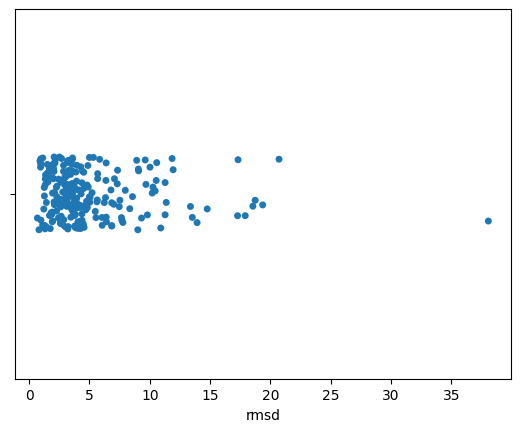

In [28]:
df = singles["loops_top"]
sns.stripplot(x=df[df["loops_missing"]==False]["rmsd"])

<AxesSubplot: xlabel='rmsd'>

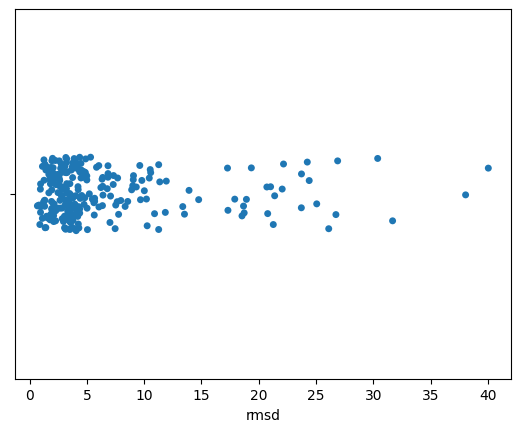

In [29]:
sns.stripplot(x=df["rmsd"])

/home/paul/miniconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot: xlabel='rmsd'>

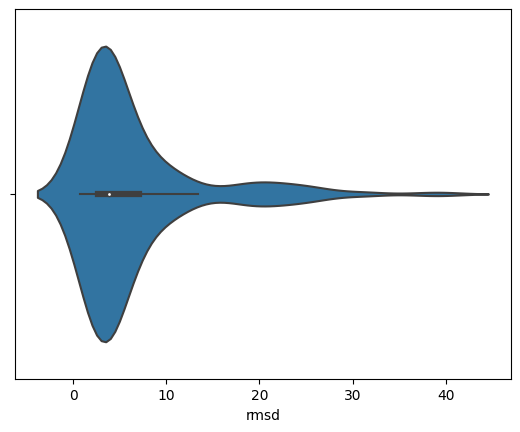

In [30]:
sns.violinplot(singles["loops_top"]["rmsd"])

In [31]:
#fn = fn.drop(columns=["DIR", "REAL_DIR"]).join(info.drop(columns=["DIR", "REAL_DIR"]))

<AxesSubplot: xlabel='num_nucs', ylabel='rmsd'>

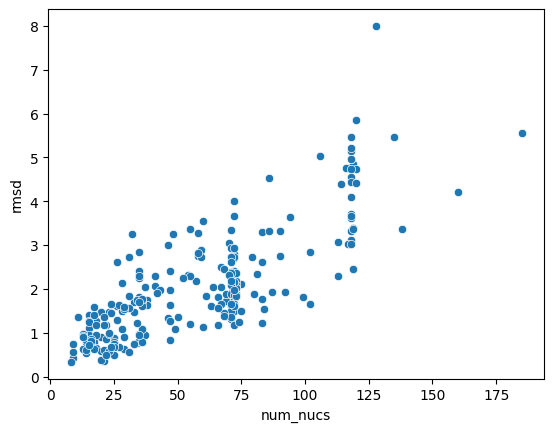

In [32]:
sns.scatterplot(x = fn["num_nucs"], y=fn["rmsd"])

<AxesSubplot: title={'center': 'Distribution of molecule sizes'}, xlabel='Number of nucleotides (excluding dangling ends)', ylabel='Existence of multi-way junctions'>

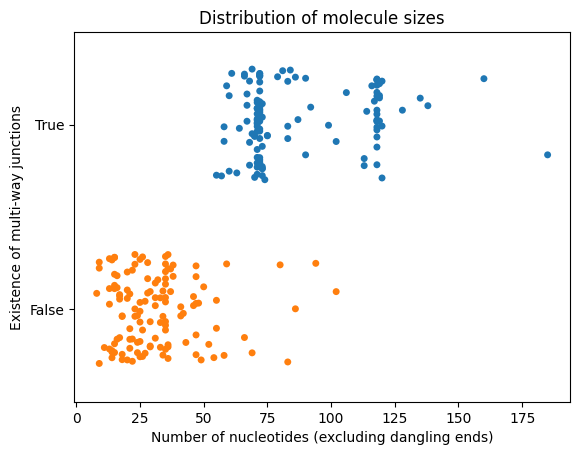

In [33]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )
p = sns.stripplot(     jitter=0.3,        
        data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
        x="num_nucs",  y="has_junctions",
             )
import matplotlib.pyplot as plt
#p.add_line(plt.Line2D([20,20], [-0.4,1.4], color="red", linestyle="--"))
plt.title("Distribution of molecule sizes")
plt.ylabel("Existence of multi-way junctions")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
p

<AxesSubplot: title={'center': 'Distribution of molecule sizes'}, xlabel='Number of nucleotides (excluding dangling ends)', ylabel='Type of junction'>

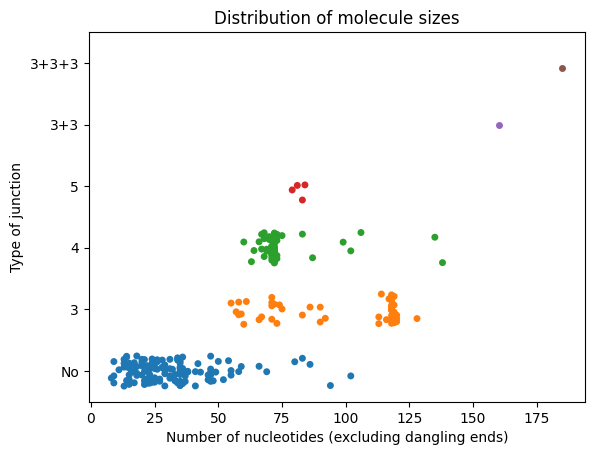

In [34]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )
np.random.seed(120)
p = sns.stripplot(    jitter=0.25,        
        data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
        x="num_nucs",  y="junction_profile", hue = "junction_profile",
                  order= reversed(["No", "3", "4", "5", "3+3", "3+3+3"]),
                  hue_order= (["No", "3", "4", "5", "3+3", "3+3+3"])
             )
import matplotlib.pyplot as plt
#p.add_line(plt.Line2D([20,20], [-0.4,1.4], color="red", linestyle="--"))
plt.title("Distribution of molecule sizes")
plt.ylabel("Type of junction")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.legend().remove()
p

<AxesSubplot: title={'center': 'Distribution of molecule sizes'}, xlabel='Number of nucleotides (excluding dangling ends)', ylabel='Number of paired nucleotides in the secondary structure'>

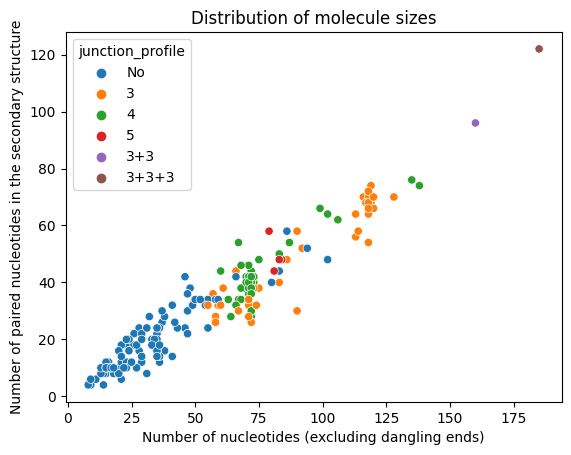

In [35]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )
p = sns.scatterplot(            
        data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
        x="num_nucs",  y="num_paired", hue = "junction_profile",
                  hue_order= (["No", "3", "4", "5", "3+3", "3+3+3"])
             )
import matplotlib.pyplot as plt
#p.add_line(plt.Line2D([20,20], [-0.4,1.4], color="red", linestyle="--"))
plt.title("Distribution of molecule sizes")
plt.ylabel("Number of paired nucleotides in the secondary structure")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
p

In [36]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )
import plotly.express as px

p = px.scatter(            
        data_frame = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a="").reset_index(),
        x="num_nucs",  y="num_paired", color = "junction_profile", hover_name="name", hover_data=["pdb_chains"],
                  #hue_order= (["No", "3", "4", "5", "3+3", "3+3+3"])
             )
p

In [37]:
#data

In [38]:
" ".join([a + "" for a in (info[(116 <= info["num_nucs"]) & (info["num_nucs"] <= 120)].index)])

'NR_4.0_07539.1 NR_4.0_10157.105 NR_4.0_10255.27 NR_4.0_11525.1 NR_4.0_17605.2 NR_4.0_18586.49 NR_4.0_20401.1 NR_4.0_21609.1 NR_4.0_36108.1 NR_4.0_42467.1 NR_4.0_42832.1 NR_4.0_43536.1 NR_4.0_49345.1 NR_4.0_51489.1 NR_4.0_52752.14 NR_4.0_55569.1 NR_4.0_62824.1 NR_4.0_64727.1 NR_4.0_65336.1 NR_4.0_69984.2 NR_4.0_71748.1 NR_4.0_75628.1 NR_4.0_79566.1 NR_4.0_83277.1 NR_4.0_96182.1'

In [39]:
(info[(116 <= info["num_nucs"]) & (info["num_nucs"] <= 120)])

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_07539.1,8EUG|1|9,"8EUG|1|9,8EUI|1|9",118,118,72,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_10157.105,5J7L|1|DB,"5J7L|1|DB,5JC9|1|DB,5J8A|1|DB,4YBB|1|DB,6I7V|1...",119,120,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_10255.27,7O7Y|1|B7,"7O7Y|1|B7,7OYD|1|K,7O7Z|1|B7,7UCK|1|7,7OBR|1|7...",118,120,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_11525.1,7R81|1|B1,7R81|1|B1,119,120,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_17605.2,3J79|1|B,"3J79|1|B,5UMD|1|B",116,118,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_18586.49,5TBW|1|AS,"5TBW|1|AS,5TBW|1|3,4V88|1|A3,4V88|1|A7,7OSA|1|...",120,121,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_20401.1,7QCA|1|L70,7QCA|1|L70,118,119,68,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_21609.1,7CPU|1|L7,"7CPU|1|L7,7CPV|1|L7,7LS2|1|B2,6SWA|1|s,7LS1|1|B2",118,120,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_36108.1,7OLC|1|3,"7OLC|1|3,7OLD|1|3",119,119,68,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [40]:
" ".join([a + ".pdb" for a in (info[(60 <= info["num_nucs"]) & (info["num_nucs"] <= 80) & (info["junction_profile"] == "4")].index)])

'NR_4.0_01147.1.pdb NR_4.0_04000.1.pdb NR_4.0_04935.1.pdb NR_4.0_04953.1.pdb NR_4.0_11374.1.pdb NR_4.0_12290.1.pdb NR_4.0_14254.1.pdb NR_4.0_19951.61.pdb NR_4.0_20115.1.pdb NR_4.0_20230.1.pdb NR_4.0_20585.1.pdb NR_4.0_20951.1.pdb NR_4.0_21015.2.pdb NR_4.0_22323.3.pdb NR_4.0_23520.1.pdb NR_4.0_25652.1.pdb NR_4.0_26825.1.pdb NR_4.0_30383.1.pdb NR_4.0_30612.1.pdb NR_4.0_31819.5.pdb NR_4.0_33997.1.pdb NR_4.0_36393.1.pdb NR_4.0_37355.1.pdb NR_4.0_40788.1.pdb NR_4.0_41924.1.pdb NR_4.0_44698.1.pdb NR_4.0_45040.1.pdb NR_4.0_45098.2.pdb NR_4.0_45609.5.pdb NR_4.0_45742.1.pdb NR_4.0_46186.1.pdb NR_4.0_47349.1.pdb NR_4.0_47714.1.pdb NR_4.0_51130.1.pdb NR_4.0_53333.1.pdb NR_4.0_56204.1.pdb NR_4.0_62940.1.pdb NR_4.0_64397.1.pdb NR_4.0_64404.2.pdb NR_4.0_65114.1.pdb NR_4.0_65615.1.pdb NR_4.0_65635.3.pdb NR_4.0_69638.1.pdb NR_4.0_69813.10.pdb NR_4.0_70420.1.pdb NR_4.0_71445.1.pdb NR_4.0_72196.1.pdb NR_4.0_73795.1.pdb NR_4.0_74018.1.pdb NR_4.0_76729.1.pdb NR_4.0_77343.3.pdb NR_4.0_79129.1.pdb NR_4.0_79

In [41]:
(info[(116 <= info["num_nucs"]) & (info["num_nucs"] <= 120)])

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_07539.1,8EUG|1|9,"8EUG|1|9,8EUI|1|9",118,118,72,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_10157.105,5J7L|1|DB,"5J7L|1|DB,5JC9|1|DB,5J8A|1|DB,4YBB|1|DB,6I7V|1...",119,120,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_10255.27,7O7Y|1|B7,"7O7Y|1|B7,7OYD|1|K,7O7Z|1|B7,7UCK|1|7,7OBR|1|7...",118,120,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_11525.1,7R81|1|B1,7R81|1|B1,119,120,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_17605.2,3J79|1|B,"3J79|1|B,5UMD|1|B",116,118,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_18586.49,5TBW|1|AS,"5TBW|1|AS,5TBW|1|3,4V88|1|A3,4V88|1|A7,7OSA|1|...",120,121,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_20401.1,7QCA|1|L70,7QCA|1|L70,118,119,68,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_21609.1,7CPU|1|L7,"7CPU|1|L7,7CPV|1|L7,7LS2|1|B2,6SWA|1|s,7LS1|1|B2",118,120,70,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_36108.1,7OLC|1|3,"7OLC|1|3,7OLD|1|3",119,119,68,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [42]:
" ".join([a + ".pdb" for a in (info[(30 <= info["num_nucs"]) & (info["num_nucs"] <= 40)].index)])

'NR_4.0_02963.1.pdb NR_4.0_08239.1.pdb NR_4.0_14947.1.pdb NR_4.0_18718.1.pdb NR_4.0_22747.1.pdb NR_4.0_23939.1.pdb NR_4.0_24216.1.pdb NR_4.0_25919.1.pdb NR_4.0_26426.2.pdb NR_4.0_35127.1.pdb NR_4.0_39458.1.pdb NR_4.0_40597.1.pdb NR_4.0_41425.1.pdb NR_4.0_47265.1.pdb NR_4.0_48165.1.pdb NR_4.0_49782.1.pdb NR_4.0_52747.1.pdb NR_4.0_53766.1.pdb NR_4.0_56838.1.pdb NR_4.0_57443.1.pdb NR_4.0_62367.1.pdb NR_4.0_65533.1.pdb NR_4.0_66108.1.pdb NR_4.0_70098.1.pdb NR_4.0_70895.1.pdb NR_4.0_73108.1.pdb NR_4.0_78506.1.pdb NR_4.0_87561.1.pdb NR_4.0_91105.1.pdb NR_4.0_92029.1.pdb NR_4.0_93701.1.pdb'

In [43]:
(info[(32 <= info["num_nucs"]) & (info["num_nucs"] <= 38)])

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_02963.1,5DEA|1|C,"5DEA|1|C,5DE5|1|C,5DE8|1|C",35,35,14,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_08239.1,6E8S|1|A,"6E8S|1|A,6E8S|1|B,6UP0|1|D,6UP0|1|C",38,38,16,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_14947.1,1KOG|1|O,"1KOG|1|O,1KOG|1|J,1KOG|1|M,1KOG|1|P,1KOG|1|L,1...",37,37,26,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_18718.1,4PDB|1|I,4PDB|1|I,38,38,28,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_22747.1,2OZB|1|C,"2OZB|1|C,2OZB|1|F",33,33,20,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_23939.1,4C4W|1|H,"4C4W|1|H,4C4W|1|D",35,35,16,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_24216.1,8D29|1|C,"8D29|1|C,8D29|1|R",34,34,18,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_25919.1,6CF2|1|G,6CF2|1|G,35,35,22,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_26426.2,6C63|1|A,"6C63|1|A,6C63|1|B,6C65|1|A,6C65|1|B,6C64|1|A,6...",36,36,12,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False


In [44]:
"~/pymol/pymol "+" ".join([a + ".pdb" for a in (info[ info["junction_profile"] == "5" ]).index])

'~/pymol/pymol NR_4.0_13919.1.pdb NR_4.0_37397.1.pdb NR_4.0_46102.2.pdb NR_4.0_93290.1.pdb'

In [45]:
info[ info["junction_profile"] == "5" ]

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_13919.1,3AM1|1|B,3AM1|1|B,79,81,58,1,5,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_37397.1,6Z6M|1|CC,6Z6M|1|CC,81,85,44,1,5,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_46102.2,1WZ2|1|D,"1WZ2|1|D,1WZ2|1|C",84,88,48,1,5,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_93290.1,6ZMO|1|CB,6ZMO|1|CB,83,87,48,1,5,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [46]:
info.loc[["NR_4.0_47162.1", "NR_4.0_33922.2"]]

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_47162.1,3PDR|1|X,"3PDR|1|X,3PDR|1|A,2QBZ|1|X",160,161,96,2,3+3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_33922.2,4R4V|1|A,"4R4V|1|A,5V3I|1|A,4R4P|1|A",185,185,122,3,3+3+3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [47]:

import pandas as pd
import plotly.express as px
import numpy as np



p = px.strip(     #jitter=0.3,        
        data_frame = info.reset_index().replace({"has_junctions": {False: "False", True: "True"}}),
        x="num_nucs",  y="junction_profile", hover_name = "name", hover_data=["name", "pdb_chains"],
            # range_y = (-0.1, 1.1),
        height = 1500
             )
p

In [48]:
info.replace({"has_junctions": {False: "False", True: "True"}})

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_00361.1,7LYG|1|A,7LYG|1|A,138,142,74,1,4,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_00810.1,4C7O|1|E,4C7O|1|E,48,48,38,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01147.1,6GZ4|1|Bw,6GZ4|1|Bw,72,76,40,1,4,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_01689.1,6KYV|1|G,"6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...",22,22,18,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01806.1,3IAB|1|R,3IAB|1|R,46,46,24,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
...,...,...,...,...,...,...,...,...,...,...
NR_4.0_96274.1,6T4Q|1|7,"6T4Q|1|7,6Q8Y|1|m,6T7I|1|7",71,75,34,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_97773.1,6YDP|1|AV,"6YDP|1|AV,7NQL|1|AV,7NQH|1|AV",67,71,30,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_98593.1,5D8H|1|A,5D8H|1|A,74,74,32,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [49]:
fn

,,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,has_junctions,num_loops,num_loops_found,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK,loops_missing
name,instance,,,,,,,,,,,,,,,,,,
NR_4.0_00361.1,1,7LYG|1|A,7LYG|1|A,138,142,74,1,4,True,10,10,3.354979,0.000000e+00,3.635884,0.922741,0.988826,0.670820,0.903696,False
NR_4.0_00810.1,1,4C7O|1|E,4C7O|1|E,48,48,38,0,No,False,4,4,3.259122,0.000000e+00,3.530586,0.923111,1.000000,1.000000,0.880078,False
NR_4.0_01147.1,1,6GZ4|1|Bw,6GZ4|1|Bw,72,76,40,1,4,True,5,5,1.596263,0.000000e+00,1.797885,0.887856,0.977008,0.516398,0.880391,False
NR_4.0_01689.1,1,6KYV|1|G,"6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...",22,22,18,0,No,False,1,1,1.166121,4.247957e-07,1.235868,0.943564,1.000000,1.000000,0.909509,False
NR_4.0_01806.1,1,3IAB|1|R,3IAB|1|R,46,46,24,0,No,False,2,2,1.334821,0.000000e+00,1.415719,0.942857,1.000000,-1.000000,0.913043,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NR_4.0_96274.1,1,6T4Q|1|7,"6T4Q|1|7,6Q8Y|1|m,6T7I|1|7",71,75,34,1,3,True,3,3,1.650925,0.000000e+00,1.802863,0.915724,0.974679,0.857143,0.902698,False
NR_4.0_97773.1,1,6YDP|1|AV,"6YDP|1|AV,7NQL|1|AV,7NQH|1|AV",67,71,30,1,3,True,4,4,2.051232,0.000000e+00,2.183570,0.939394,1.000000,0.500000,0.928571,False
NR_4.0_98593.1,1,5D8H|1|A,5D8H|1|A,74,74,32,1,3,True,5,5,1.252860,0.000000e+00,1.327057,0.944089,0.974679,0.894427,0.941858,False


In [50]:
values = list(set(df.columns) - {"pdb_chains", "num_nucs"})
df[df[values].isna().any(axis=1)]

,,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,has_junctions,num_loops,num_loops_found,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK,loops_missing
name,instance,,,,,,,,,,,,,,,,,,


In [51]:
to_concat = []
methods = []
for k,v in singles.items():
    to_concat.append(v.assign(method=k).assign(multi=False))
    methods.append(k)
for k,v in multis.items():
    to_concat.append(v.assign(method=k).assign(multi=True))
    methods.append(k)

all_data = pd.concat(to_concat).reset_index().set_index([ "name", "method", "instance"])
all_data

pdb_chains  \
name           method      instance              
NR_4.0_00361.1 from_native 1          7LYG|1|A   
NR_4.0_00810.1 from_native 1          4C7O|1|E   
NR_4.0_01147.1 from_native 1         6GZ4|1|Bw   
NR_4.0_01689.1 from_native 1          6KYV|1|G   
NR_4.0_01806.1 from_native 1          3IAB|1|R   
...                                        ...   
NR_4.0_99276.1 bp2_all     out_0_5    7ONB|1|H   
                           out_0_6    7ONB|1|H   
                           out_0_7    7ONB|1|H   
                           out_0_8    7ONB|1|H   
                           out_0_9    7ONB|1|H   

                                                             equivalent_nrlist_entries  \
name           method      instance                                                      
NR_4.0_00361.1 from_native 1                                                  7LYG|1|A   
NR_4.0_00810.1 from_native 1                                                  4C7O|1|E   
NR_4.0_01147.1 from_native 1                                                 6GZ4|1|Bw   
NR_4.0_01689.1 from_native 1         6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...   
NR_4.0_01806.1 from_native 1                                                  3IAB|1|R   
...                                                                                ...   
NR_4.0_99276.1 bp2_all     out_0_5                                            7ONB|1|H   
                           out_0_6                                            7ONB|1|H   
                           out_0_7                                            7ONB|1|H   
                           out_0_8                                            7ONB|1|H   
                           out_0_9                                            7ONB|1|H   

                                     num_nucs  num_nucs_with_dangling  \
name           method      instance                                     
NR_4.0_00361.1 from_native 1              138                     142   
NR_4.0_00810.1 from_native 1               48                      48   
NR_4.0_01147.1 from_native 1               72                      76   
NR_4.0_01689.1 from_native 1               22                      22   
NR_4.0_01806.1 from_native 1               46                      46   
...                                       ...                     ...   
NR_4.0_99276.1 bp2_all     out_0_5         18                      32   
                           out_0_6         18                      32   
                           out_0_7         18                      32   
                           out_0_8         18                      32   
                           out_0_9         18                      32   

                                     num_paired  num_junctions  \
name           method      instance                              
NR_4.0_00361.1 from_native 1                 74              1   
NR_4.0_00810.1 from_native 1                 38              0   
NR_4.0_01147.1 from_native 1                 40              1   
NR_4.0_01689.1 from_native 1                 18              0   
NR_4.0_01806.1 from_native 1                 24              0   
...                                         ...            ...   
NR_4.0_99276.1 bp2_all     out_0_5           10              0   
                           out_0_6           10              0   
                           out_0_7           10              0   
                           out_0_8           10              0   
                           out_0_9           10              0   

                                    junction_profile  has_junctions  \
name           method      instance                                   
NR_4.0_00361.1 from_native 1                       4           True   
NR_4.0_00810.1 from_native 1                      No          False   
NR_4.0_01147.1 from_native 1                       4           True   
NR_4.0_01689.1 from_native 1                      

In [52]:
#all_data.loc[("NR_4.0_00361.1", "1")]

In [53]:
all_data

pdb_chains  \
name           method      instance              
NR_4.0_00361.1 from_native 1          7LYG|1|A   
NR_4.0_00810.1 from_native 1          4C7O|1|E   
NR_4.0_01147.1 from_native 1         6GZ4|1|Bw   
NR_4.0_01689.1 from_native 1          6KYV|1|G   
NR_4.0_01806.1 from_native 1          3IAB|1|R   
...                                        ...   
NR_4.0_99276.1 bp2_all     out_0_5    7ONB|1|H   
                           out_0_6    7ONB|1|H   
                           out_0_7    7ONB|1|H   
                           out_0_8    7ONB|1|H   
                           out_0_9    7ONB|1|H   

                                                             equivalent_nrlist_entries  \
name           method      instance                                                      
NR_4.0_00361.1 from_native 1                                                  7LYG|1|A   
NR_4.0_00810.1 from_native 1                                                  4C7O|1|E   
NR_4.0_01147.1 from_native 1                                                 6GZ4|1|Bw   
NR_4.0_01689.1 from_native 1         6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...   
NR_4.0_01806.1 from_native 1                                                  3IAB|1|R   
...                                                                                ...   
NR_4.0_99276.1 bp2_all     out_0_5                                            7ONB|1|H   
                           out_0_6                                            7ONB|1|H   
                           out_0_7                                            7ONB|1|H   
                           out_0_8                                            7ONB|1|H   
                           out_0_9                                            7ONB|1|H   

                                     num_nucs  num_nucs_with_dangling  \
name           method      instance                                     
NR_4.0_00361.1 from_native 1              138                     142   
NR_4.0_00810.1 from_native 1               48                      48   
NR_4.0_01147.1 from_native 1               72                      76   
NR_4.0_01689.1 from_native 1               22                      22   
NR_4.0_01806.1 from_native 1               46                      46   
...                                       ...                     ...   
NR_4.0_99276.1 bp2_all     out_0_5         18                      32   
                           out_0_6         18                      32   
                           out_0_7         18                      32   
                           out_0_8         18                      32   
                           out_0_9         18                      32   

                                     num_paired  num_junctions  \
name           method      instance                              
NR_4.0_00361.1 from_native 1                 74              1   
NR_4.0_00810.1 from_native 1                 38              0   
NR_4.0_01147.1 from_native 1                 40              1   
NR_4.0_01689.1 from_native 1                 18              0   
NR_4.0_01806.1 from_native 1                 24              0   
...                                         ...            ...   
NR_4.0_99276.1 bp2_all     out_0_5           10              0   
                           out_0_6           10              0   
                           out_0_7           10              0   
                           out_0_8           10              0   
                           out_0_9           10              0   

                                    junction_profile  has_junctions  \
name           method      instance                                   
NR_4.0_00361.1 from_native 1                       4           True   
NR_4.0_00810.1 from_native 1                      No          False   
NR_4.0_01147.1 from_native 1                       4           True   
NR_4.0_01689.1 from_native 1                      

<AxesSubplot: xlabel='method', ylabel='num_nucs'>

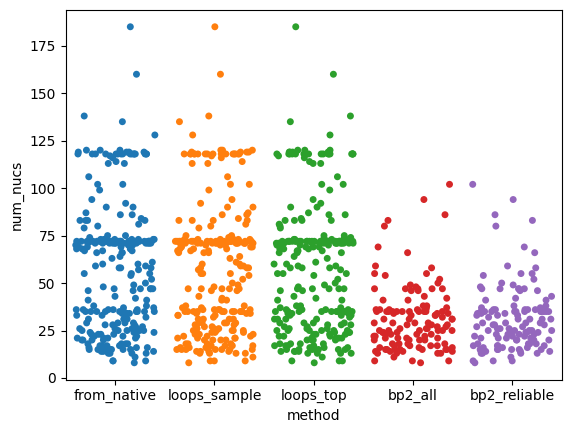

In [54]:
sns.stripplot(jitter=0.4, data = all_data["num_nucs"].groupby(["name", "method"]).mean().reset_index(), x = "method", y = "num_nucs")



In [55]:
all_data[all_data["rmsd"].isna()]

,,,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,has_junctions,num_loops,num_loops_found,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK,loops_missing,multi
name,method,instance,,,,,,,,,,,,,,,,,,,


In [56]:
all_data[all_data["num_nucs"] >= 20]

pdb_chains  \
name           method      instance              
NR_4.0_00361.1 from_native 1          7LYG|1|A   
NR_4.0_00810.1 from_native 1          4C7O|1|E   
NR_4.0_01147.1 from_native 1         6GZ4|1|Bw   
NR_4.0_01689.1 from_native 1          6KYV|1|G   
NR_4.0_01806.1 from_native 1          3IAB|1|R   
...                                        ...   
NR_4.0_95874.1 bp2_all     out_0_5    3R9X|1|C   
                           out_0_6    3R9X|1|C   
                           out_0_7    3R9X|1|C   
                           out_0_8    3R9X|1|C   
                           out_0_9    3R9X|1|C   

                                                             equivalent_nrlist_entries  \
name           method      instance                                                      
NR_4.0_00361.1 from_native 1                                                  7LYG|1|A   
NR_4.0_00810.1 from_native 1                                                  4C7O|1|E   
NR_4.0_01147.1 from_native 1                                                 6GZ4|1|Bw   
NR_4.0_01689.1 from_native 1         6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...   
NR_4.0_01806.1 from_native 1                                                  3IAB|1|R   
...                                                                                ...   
NR_4.0_95874.1 bp2_all     out_0_5                                            3R9X|1|C   
                           out_0_6                                            3R9X|1|C   
                           out_0_7                                            3R9X|1|C   
                           out_0_8                                            3R9X|1|C   
                           out_0_9                                            3R9X|1|C   

                                     num_nucs  num_nucs_with_dangling  \
name           method      instance                                     
NR_4.0_00361.1 from_native 1              138                     142   
NR_4.0_00810.1 from_native 1               48                      48   
NR_4.0_01147.1 from_native 1               72                      76   
NR_4.0_01689.1 from_native 1               22                      22   
NR_4.0_01806.1 from_native 1               46                      46   
...                                       ...                     ...   
NR_4.0_95874.1 bp2_all     out_0_5         24                      35   
                           out_0_6         24                      35   
                           out_0_7         24                      35   
                           out_0_8         24                      35   
                           out_0_9         24                      35   

                                     num_paired  num_junctions  \
name           method      instance                              
NR_4.0_00361.1 from_native 1                 74              1   
NR_4.0_00810.1 from_native 1                 38              0   
NR_4.0_01147.1 from_native 1                 40              1   
NR_4.0_01689.1 from_native 1                 18              0   
NR_4.0_01806.1 from_native 1                 24              0   
...                                         ...            ...   
NR_4.0_95874.1 bp2_all     out_0_5           16              0   
                           out_0_6           16              0   
                           out_0_7           16              0   
                           out_0_8           16              0   
                           out_0_9           16              0   

                                    junction_profile  has_junctions  \
name           method      instance                                   
NR_4.0_00361.1 from_native 1                       4           True   
NR_4.0_00810.1 from_native 1                      No          False   
NR_4.0_01147.1 from_native 1                       4           True   
NR_4.0_01689.1 from_native 1                      

In [57]:
# # calculate mean and variance of all molecules
# df = all_data
# df = df[df["num_nucs"] >= 20]
# df = df[df["rmsd"].isna() == False]

In [58]:
df = all_data
no_junctions = list(set([a[0] for a in (df[df["has_junctions"] == False].index)]))

In [59]:
no_junctions

['NR_4.0_56099.1',
 'NR_4.0_81641.1',
 'NR_4.0_51660.3',
 'NR_4.0_14903.1',
 'NR_4.0_48165.1',
 'NR_4.0_90603.1',
 'NR_4.0_75875.1',
 'NR_4.0_06780.1',
 'NR_4.0_72335.1',
 'NR_4.0_44743.1',
 'NR_4.0_56838.1',
 'NR_4.0_02491.1',
 'NR_4.0_60411.1',
 'NR_4.0_52747.1',
 'NR_4.0_66108.1',
 'NR_4.0_75028.1',
 'NR_4.0_83665.1',
 'NR_4.0_65600.1',
 'NR_4.0_52535.1',
 'NR_4.0_15508.1',
 'NR_4.0_95874.1',
 'NR_4.0_57646.1',
 'NR_4.0_26576.1',
 'NR_4.0_10362.1',
 'NR_4.0_49782.1',
 'NR_4.0_16758.1',
 'NR_4.0_27023.1',
 'NR_4.0_27557.1',
 'NR_4.0_70662.1',
 'NR_4.0_99276.1',
 'NR_4.0_37028.1',
 'NR_4.0_23939.1',
 'NR_4.0_11942.1',
 'NR_4.0_41425.1',
 'NR_4.0_26426.2',
 'NR_4.0_25919.1',
 'NR_4.0_53827.1',
 'NR_4.0_23835.1',
 'NR_4.0_07004.1',
 'NR_4.0_18718.1',
 'NR_4.0_08043.1',
 'NR_4.0_40597.1',
 'NR_4.0_94113.1',
 'NR_4.0_52614.1',
 'NR_4.0_22747.1',
 'NR_4.0_78506.1',
 'NR_4.0_57955.2',
 'NR_4.0_14947.1',
 'NR_4.0_46884.1',
 'NR_4.0_23975.1',
 'NR_4.0_36231.1',
 'NR_4.0_04852.2',
 'NR_4.0_524

In [60]:
data_noj = all_data.loc[no_junctions]

In [61]:
data_noj["rmsd"].groupby(["method"]).mean()

method
bp2_all         7.298994
bp2_reliable    9.528189
from_native     1.408970
loops_sample    5.579047
loops_top       4.064467
Name: rmsd, dtype: float64

In [62]:
data_noj["rmsd"].groupby(["method"]).var()

method
bp2_all         32.923369
bp2_reliable    53.002446
from_native      0.631370
loops_sample    16.224524
loops_top       11.526789
Name: rmsd, dtype: float64

In [63]:
no_bp = ["from_native", "loops_top", "loops_sample"]
data_j = all_data.reset_index().set_index("method").loc[no_bp].reset_index().set_index(["name", "method", "instance"])

In [64]:
data_j["rmsd"].groupby(["method"]).mean()

method
from_native     2.068887
loops_sample    7.723516
loops_top       6.485846
Name: rmsd, dtype: float64

In [65]:
data_j["rmsd"].groupby(["method"]).var()

method
from_native      1.531840
loops_sample    47.684358
loops_top       46.508384
Name: rmsd, dtype: float64

In [66]:
def over_all(data):
    df = pd.DataFrame()
    dd = data[data["num_nucs"] < 20]
    for measure in ["rmsd", "INF_ALL", "DI_ALL"]:
        df[measure +"_mean"] = dd[measure].groupby(["method"]).mean()
        df[measure + "_var"] = dd[measure].groupby(["method"]).var()
    dflt = df
    df = pd.DataFrame()
    dd = data[data["num_nucs"] >= 20]
    for measure in ["rmsd", "INF_ALL", "DI_ALL"]:
        df[measure +"_mean"] = dd[measure].groupby(["method"]).mean()
        df[measure + "_var"] = dd[measure].groupby(["method"]).var()
    dfge = df
    return pd.concat([dflt.assign(size="<20"), dfge.assign(size=">=20")]).reset_index().set_index(["size", "method"]) 

In [67]:
over_all(data_noj)  # Means over the dataset that has no junction

rmsd_mean   rmsd_var  INF_ALL_mean  INF_ALL_var  \
size method                                                          
<20  bp2_all        4.087165   3.654663      0.757032     0.012050   
     bp2_reliable   4.040271   3.076777      0.783993     0.008637   
     from_native    0.901799   0.098478      0.937412     0.001738   
     loops_sample   3.728319   4.853984      0.789616     0.012160   
     loops_top      2.640916   3.194002      0.828372     0.012219   
>=20 bp2_all        8.358215  38.053701      0.756310     0.014413   
     bp2_reliable  11.338034  56.260822      0.724101     0.015665   
     from_native    1.576228   0.696043      0.947279     0.000726   
     loops_sample   6.189393  18.473787      0.780234     0.013553   
     loops_top      4.533936  13.440459      0.748364     0.148314   

                   DI_ALL_mean  DI_ALL_var  
size method                                 
<20  bp2_all          5.760914   11.096196  
     bp2_reliable     5.386865    7.738186  
     from_native      0.971263    0.129796  
     loops_sample     5.155899   14.305264  
     loops_top        3.546629    9.297225  
>=20 bp2_all         12.570534  138.258715  
     bp2_reliable    17.620363  200.358245  
     from_native      1.673877    0.818522  
     loops_sample     8.778932   52.806426  
     loops_top        5.666179   38.997295

In [68]:
over_all(data_j)  # Means over the whole dataset

rmsd_mean   rmsd_var  INF_ALL_mean  INF_ALL_var  \
size method                                                          
<20  from_native    0.901799   0.098478      0.937412     0.001738   
     loops_sample   3.728319   4.853984      0.789616     0.012160   
     loops_top      2.640916   3.194002      0.828372     0.012219   
>=20 from_native    2.234849   1.514805      0.931138     0.001139   
     loops_sample   8.291640  51.183149      0.781163     0.009311   
     loops_top      7.032602  50.298625      0.743305     0.124629   

                   DI_ALL_mean  DI_ALL_var  
size method                                 
<20  from_native      0.971263    0.129796  
     loops_sample     5.155899   14.305264  
     loops_top        3.546629    9.297225  
>=20 from_native      2.405420    1.710767  
     loops_sample    11.410931  119.526157  
     loops_top        8.996629  120.241954

In [69]:
data_j[data_j["num_loops"] != data_j["num_loops_found"]]

pdb_chains  \
name           method       instance              
NR_4.0_04000.1 loops_top    1          6ZM6|1|w   
NR_4.0_14254.1 loops_top    1          7LJ3|1|A   
NR_4.0_20585.1 loops_top    1         6ORD|1|QY   
NR_4.0_25652.1 loops_top    1         5MRC|1|bb   
NR_4.0_26576.1 loops_top    1          4LCK|1|F   
...                                         ...   
NR_4.0_98802.1 loops_sample 50         6DLR|1|A   
                            6          6DLR|1|A   
                            7          6DLR|1|A   
                            8          6DLR|1|A   
                            9          6DLR|1|A   

                                                              equivalent_nrlist_entries  \
name           method       instance                                                      
NR_4.0_04000.1 loops_top    1                                         6ZM6|1|w,6ZM5|1|w   
NR_4.0_14254.1 loops_top    1                                7LJ3|1|A,7LJ3|1|C,7LJ3|1|B   
NR_4.0_20585.1 loops_top    1         6ORD|1|QY,6ORD|1|XY,6OJ2|1|XY,6OPE|1|QY,6OPE|1...   
NR_4.0_25652.1 loops_top    1                                       5MRC|1|bb,5MRE|1|bb   
NR_4.0_26576.1 loops_top    1         4LCK|1|F,4LCK|1|C,4TZZ|1|C,4TZZ|1|F,4TZZ|1|I,4...   
...                                                                                 ...   
NR_4.0_98802.1 loops_sample 50             6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   
                            6              6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   
                            7              6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   
                            8              6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   
                            9              6DLR|1|A,6DLT|1|A,6DLS|1|A,6DLQ|1|A,6DNR|1|A   

                                      num_nucs  num_nucs_with_dangling  \
name           method       instance                                     
NR_4.0_04000.1 loops_top    1               64                      68   
NR_4.0_14254.1 loops_top    1               71                      75   
NR_4.0_20585.1 loops_top    1               72                      76   
NR_4.0_25652.1 loops_top    1               72                      76   
NR_4.0_26576.1 loops_top    1              102                     102   
...                                        ...                     ...   
NR_4.0_98802.1 loops_sample 50             106                     107   
                            6              106                     107   
                            7              106                     107   
                            8              106                     107   
                            9              106                     107   

                                      num_paired  num_junctions  \
name           method       instance                              
NR_4.0_04000.1 loops_top    1                 28              1   
NR_4.0_14254.1 loops_top    1                 38              1   
NR_4.0_20585.1 loops_top    1                 28              1   
NR_4.0_25652.1 loops_top    1                 26              1   
NR_4.0_26576.1 loops_top    1                 48              0   
...                                          ...            ...   
NR_4.0_98802.1 loops_sample 50                62              1   
                            6                 62              1   
                            7                 62              1   
                            8                 62              1   
                            9                 62              1   

                                     junction_profile  has_junctions  \
name           method       instance                                   
NR_4.0_04000.1 loops_top    1                       4           True   
NR_4.0_14254.1 loops_top    1                       4           True   
NR_4.0_20585.1 loops_top    1                       4           Tr

In [70]:
data_noj

pdb_chains  \
name           method       instance              
NR_4.0_56099.1 from_native  1          6F4H|1|B   
               loops_top    1          6F4H|1|B   
               loops_sample 1          6F4H|1|B   
                            10         6F4H|1|B   
                            11         6F4H|1|B   
...                                         ...   
NR_4.0_73731.2 bp2_all      out_0_5    3U4M|1|B   
                            out_0_6    3U4M|1|B   
                            out_0_7    3U4M|1|B   
                            out_0_8    3U4M|1|B   
                            out_0_9    3U4M|1|B   

                                                              equivalent_nrlist_entries  \
name           method       instance                                                      
NR_4.0_56099.1 from_native  1                                         6F4H|1|B,6F4H|1|F   
               loops_top    1                                         6F4H|1|B,6F4H|1|F   
               loops_sample 1                                         6F4H|1|B,6F4H|1|F   
                            10                                        6F4H|1|B,6F4H|1|F   
                            11                                        6F4H|1|B,6F4H|1|F   
...                                                                                 ...   
NR_4.0_73731.2 bp2_all      out_0_5   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   
                            out_0_6   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   
                            out_0_7   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   
                            out_0_8   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   
                            out_0_9   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   

                                      num_nucs  num_nucs_with_dangling  \
name           method       instance                                     
NR_4.0_56099.1 from_native  1               22                      22   
               loops_top    1               22                      22   
               loops_sample 1               22                      22   
                            10              22                      22   
                            11              22                      22   
...                                        ...                     ...   
NR_4.0_73731.2 bp2_all      out_0_5         80                      80   
                            out_0_6         80                      80   
                            out_0_7         80                      80   
                            out_0_8         80                      80   
                            out_0_9         80                      80   

                                      num_paired  num_junctions  \
name           method       instance                              
NR_4.0_56099.1 from_native  1                 12              0   
               loops_top    1                 12              0   
               loops_sample 1                 12              0   
                            10                12              0   
                            11                12              0   
...                                          ...            ...   
NR_4.0_73731.2 bp2_all      out_0_5           40              0   
                            out_0_6           40              0   
                            out_0_7           40              0   
                            out_0_8           40              0   
                            out_0_9           40              0   

                                     junction_profile  has_junctions  \
name           method       instance                                   
NR_4.0_56099.1 from_native  1                      No          False   
               loops_top    1                      No          False   
               loops_sample 1                      No          Fal

In [71]:
set(data_noj[data_noj["loops_missing"] == True].reset_index()["method"])

{'bp2_all', 'bp2_reliable', 'loops_sample', 'loops_top'}

In [72]:
su = data_noj.reset_index().groupby(["name", "method"]).first().reset_index().groupby(["method", "junction_profile"])["loops_missing"].sum()

In [73]:
co = data_noj.reset_index().groupby(["name", "method"]).first().reset_index().groupby(["method", "junction_profile"])["loops_missing"].count()

In [74]:
co-su

method        junction_profile
bp2_all       No                   99
              3                     0
              4                     0
              5                     0
              3+3                   0
              3+3+3                 0
bp2_reliable  No                   47
              3                     0
              4                     0
              5                     0
              3+3                   0
              3+3+3                 0
from_native   No                  125
              3                     0
              4                     0
              5                     0
              3+3                   0
              3+3+3                 0
loops_sample  No                  124
              3                     0
              4                     0
              5                     0
              3+3                   0
              3+3+3                 0
loops_top     No                  124
              3    

In [75]:
su = data_j.reset_index().groupby(["name", "method"]).first().reset_index().groupby(["method", "junction_profile"])["loops_missing"].sum()

In [76]:
co = data_j.reset_index().groupby(["name", "method"]).first().reset_index().groupby(["method", "junction_profile"])["loops_missing"].count()

In [77]:
co-su

method        junction_profile
from_native   No                  125
              3                    51
              4                    67
              5                     4
              3+3                   1
              3+3+3                 1
loops_sample  No                  124
              3                    43
              4                    57
              5                     4
              3+3                   1
              3+3+3                 1
loops_top     No                  124
              3                    43
              4                    57
              5                     4
              3+3                   1
              3+3+3                 1
Name: loops_missing, dtype: int64

In [78]:
data_noj[data_noj["loops_missing"] == True]

pdb_chains  \
name           method       instance              
NR_4.0_56099.1 bp2_reliable out_0_0    6F4H|1|B   
                            out_0_1    6F4H|1|B   
                            out_0_10   6F4H|1|B   
                            out_0_11   6F4H|1|B   
                            out_0_12   6F4H|1|B   
...                                         ...   
NR_4.0_73731.2 bp2_all      out_0_5    3U4M|1|B   
                            out_0_6    3U4M|1|B   
                            out_0_7    3U4M|1|B   
                            out_0_8    3U4M|1|B   
                            out_0_9    3U4M|1|B   

                                                              equivalent_nrlist_entries  \
name           method       instance                                                      
NR_4.0_56099.1 bp2_reliable out_0_0                                   6F4H|1|B,6F4H|1|F   
                            out_0_1                                   6F4H|1|B,6F4H|1|F   
                            out_0_10                                  6F4H|1|B,6F4H|1|F   
                            out_0_11                                  6F4H|1|B,6F4H|1|F   
                            out_0_12                                  6F4H|1|B,6F4H|1|F   
...                                                                                 ...   
NR_4.0_73731.2 bp2_all      out_0_5   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   
                            out_0_6   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   
                            out_0_7   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   
                            out_0_8   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   
                            out_0_9   3U4M|1|B,4QVI|1|B,3UMY|1|B,4QG3|1|B,3U56|1|B,5...   

                                      num_nucs  num_nucs_with_dangling  \
name           method       instance                                     
NR_4.0_56099.1 bp2_reliable out_0_0         22                      22   
                            out_0_1         22                      22   
                            out_0_10        22                      22   
                            out_0_11        22                      22   
                            out_0_12        22                      22   
...                                        ...                     ...   
NR_4.0_73731.2 bp2_all      out_0_5         80                      80   
                            out_0_6         80                      80   
                            out_0_7         80                      80   
                            out_0_8         80                      80   
                            out_0_9         80                      80   

                                      num_paired  num_junctions  \
name           method       instance                              
NR_4.0_56099.1 bp2_reliable out_0_0           12              0   
                            out_0_1           12              0   
                            out_0_10          12              0   
                            out_0_11          12              0   
                            out_0_12          12              0   
...                                          ...            ...   
NR_4.0_73731.2 bp2_all      out_0_5           40              0   
                            out_0_6           40              0   
                            out_0_7           40              0   
                            out_0_8           40              0   
                            out_0_9           40              0   

                                     junction_profile  has_junctions  \
name           method       instance                                   
NR_4.0_56099.1 bp2_reliable out_0_0                No          False   
                            out_0_1                No          False   
                            out_0_10               No          Fal

In [79]:
data_noj_ri = data_noj.reset_index()
data_noj_ri[( data_noj_ri["method"] == "loops_top") &( data_noj_ri["junction_profile"] == "No") & (data_noj_ri["loops_missing"])]

,name,method,instance,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,...,num_loops_found,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK,loops_missing,multi
3345,NR_4.0_26576.1,loops_top,1,4LCK|1|F,"4LCK|1|F,4LCK|1|C,4TZZ|1|C,4TZZ|1|F,4TZZ|1|I,4...",102,102,48,0,No,...,6,22.168198,0.000008,32.115868,0.690257,0.905822,0.235702,0.667995,True,False


In [80]:

data_j_ri = data_j.reset_index()
data_j_ri[data_j_ri["method"] == "loops_top"].groupby(["name"]).first()


,method,instance,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,has_junctions,...,num_loops_found,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK,loops_missing,multi
name,,,,,,,,,,,,,,,,,,,,,
NR_4.0_00361.1,loops_top,1,7LYG|1|A,7LYG|1|A,138,142,74,1,4,True,...,10,13.920045,0.000000e+00,19.924302,0.698647,0.859338,0.158114,0.670139,False,False
NR_4.0_00810.1,loops_top,1,4C7O|1|E,4C7O|1|E,48,48,38,0,No,False,...,4,9.071343,6.066593e-08,10.961206,0.827586,1.000000,1.000000,0.729730,False,False
NR_4.0_01147.1,loops_top,1,6GZ4|1|Bw,6GZ4|1|Bw,72,76,40,1,4,True,...,5,3.513055,0.000000e+00,4.289848,0.818923,0.933564,0.316228,0.805464,False,False
NR_4.0_01689.1,loops_top,1,6KYV|1|G,"6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...",22,22,18,0,No,False,...,1,2.143751,5.920667e-06,2.322397,0.923077,1.000000,-1.000000,0.909509,False,False
NR_4.0_01806.1,loops_top,1,3IAB|1|R,3IAB|1|R,46,46,24,0,No,False,...,2,9.621367,1.398754e-06,13.984063,0.688024,0.960769,-1.000000,0.571040,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NR_4.0_96274.1,loops_top,1,6T4Q|1|7,"6T4Q|1|7,6Q8Y|1|m,6T7I|1|7",71,75,34,1,3,True,...,3,1.937944,0.000000e+00,2.300322,0.842466,0.927105,0.617213,0.838584,False,False
NR_4.0_97773.1,loops_top,1,6YDP|1|AV,"6YDP|1|AV,7NQL|1|AV,7NQH|1|AV",67,71,30,1,3,True,...,3,23.737221,6.212370e-01,35.820527,0.662671,0.852803,0.000000,0.692842,True,False
NR_4.0_98593.1,loops_top,1,5D8H|1|A,5D8H|1|A,74,74,32,1,3,True,...,5,3.454158,0.000000e+00,4.470884,0.772589,0.923381,0.424264,0.767731,False,False


In [81]:
info

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_00361.1,7LYG|1|A,7LYG|1|A,138,142,74,1,4,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_00810.1,4C7O|1|E,4C7O|1|E,48,48,38,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01147.1,6GZ4|1|Bw,6GZ4|1|Bw,72,76,40,1,4,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_01689.1,6KYV|1|G,"6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...",22,22,18,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01806.1,3IAB|1|R,3IAB|1|R,46,46,24,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
...,...,...,...,...,...,...,...,...,...,...
NR_4.0_96274.1,6T4Q|1|7,"6T4Q|1|7,6Q8Y|1|m,6T7I|1|7",71,75,34,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_97773.1,6YDP|1|AV,"6YDP|1|AV,7NQL|1|AV,7NQH|1|AV",67,71,30,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_98593.1,5D8H|1|A,5D8H|1|A,74,74,32,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


<AxesSubplot: title={'center': 'Molecules with loops missing from rna_insert_loops'}, xlabel='Number of nucleotides (excluding dangling ends)', ylabel='Type of junction'>

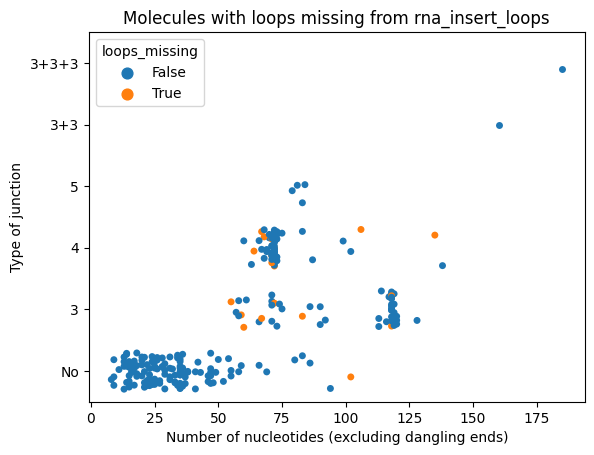

In [82]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )

data_j_ri = data_j.reset_index()
df = data_j_ri[data_j_ri["method"] == "loops_top"].groupby(["name"]).first()

np.random.seed(120)



p = sns.stripplot(    jitter=0.3,        
        data = df.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
        x="num_nucs",  y="junction_profile", hue = "loops_missing",
                  order= reversed(["No", "3", "4", "5", "3+3", "3+3+3"]),
                  #hue_order= [True, False],
                  #hue_order= (["No", "3", "4", "5", "3+3", "3+3+3"])
                  #s= 5,
             )
import matplotlib.pyplot as plt
#p.add_line(plt.Line2D([20,20], [-0.4,1.4], color="red", linestyle="--"))
plt.title("Molecules with loops missing from rna_insert_loops")
plt.ylabel("Type of junction")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.legend().remove()
p

<AxesSubplot: title={'center': 'Molecules with loops missing from BayesPairing2 RELIABLE'}, xlabel='Number of nucleotides (excluding dangling ends)', ylabel='Number of paired nucleotides in the secondary structure'>

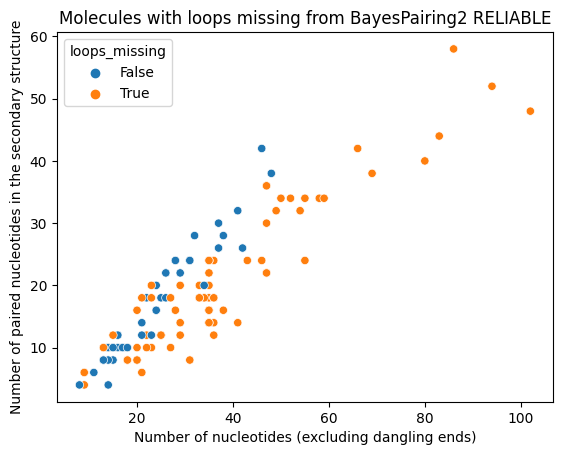

In [83]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )

data_j_ri = data_noj.reset_index()
df = data_j_ri[data_j_ri["method"] == "bp2_reliable"].groupby(["name"]).first()

np.random.seed(120)



p = sns.scatterplot(    #jitter=0.3,        
        data = df.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
        x="num_nucs",  y="num_paired", hue = "loops_missing",
                  #order= reversed(["No", "3", "4", "5", "3+3", "3+3+3"]),
                  #hue_order= [True, False],
                  #hue_order= (["No", "3", "4", "5", "3+3", "3+3+3"])
             )
import matplotlib.pyplot as plt
#p.add_line(plt.Line2D([20,20], [-0.4,1.4], color="red", linestyle="--"))
plt.title("Molecules with loops missing from BayesPairing2 RELIABLE")
plt.ylabel("Number of paired nucleotides in the secondary structure")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.legend().remove()
p

<AxesSubplot: title={'center': 'Molecules with loops missing from BayesPairing2 ALL'}, xlabel='Number of nucleotides (excluding dangling ends)', ylabel='Number of paired nucleotides in the secondary structure'>

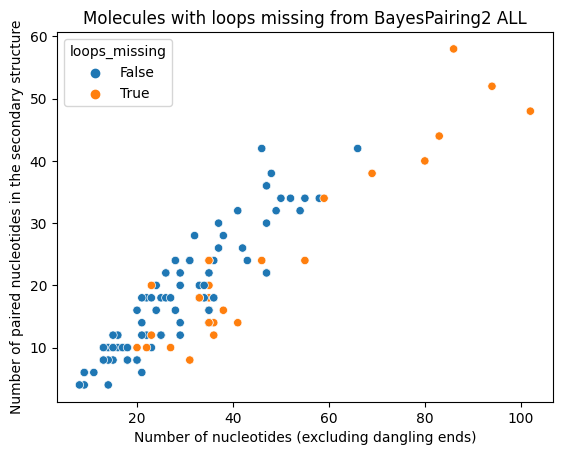

In [84]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )

data_j_ri = data_noj.reset_index()
df = data_j_ri[data_j_ri["method"] == "bp2_all"].groupby(["name"]).first()

np.random.seed(120)



p = sns.scatterplot(    #jitter=0.3,        
        data = df.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
        x="num_nucs",  y="num_paired", hue = "loops_missing",
                  #order= reversed(["No", "3", "4", "5", "3+3", "3+3+3"]),
                  #hue_order= [True, False],
                  #hue_order= (["No", "3", "4", "5", "3+3", "3+3+3"])
             )
import matplotlib.pyplot as plt
#p.add_line(plt.Line2D([20,20], [-0.4,1.4], color="red", linestyle="--"))
plt.title("Molecules with loops missing from BayesPairing2 ALL")
plt.ylabel("Number of paired nucleotides in the secondary structure")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.legend().remove()
p

<AxesSubplot: title={'center': 'Molecules with loops missing from rna_insert_loops'}, xlabel='Number of nucleotides (excluding dangling ends)', ylabel='Number of paired nucleotides in the secondary structure'>

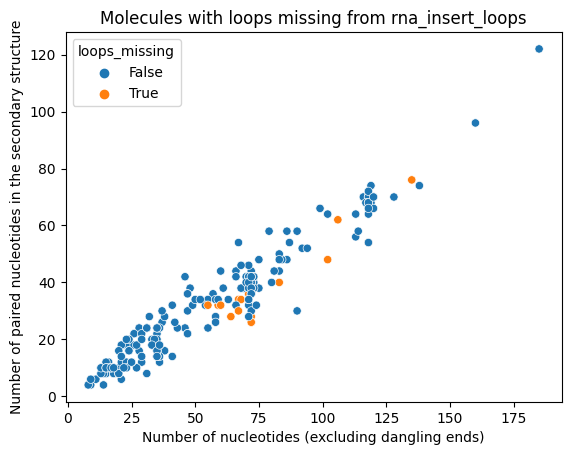

In [85]:
# p = sns.stripplot(     jitter=0.3,        
#         data = info.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
#         x="num_nucs", y="a",  hue="has_junctions",
#              )

data_j_ri = data_j.reset_index()
df = data_j_ri[data_j_ri["method"] == "loops_top"].groupby(["name"]).first()

np.random.seed(120)



p = sns.scatterplot(    #jitter=0.3,        
        data = df.replace({"has_junctions": {False: "False", True: "True"}}).assign(a=""),
        x="num_nucs",  y="num_paired", hue = "loops_missing",
                  #order= reversed(["No", "3", "4", "5", "3+3", "3+3+3"]),
                  #hue_order= [True, False],
                  #hue_order= (["No", "3", "4", "5", "3+3", "3+3+3"])
             )
import matplotlib.pyplot as plt
#p.add_line(plt.Line2D([20,20], [-0.4,1.4], color="red", linestyle="--"))
plt.title("Molecules with loops missing from rna_insert_loops")
plt.ylabel("Number of paired nucleotides in the secondary structure")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.legend().remove()
p

In [86]:
info

,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,DIR,REAL_DIR,has_junctions
name,,,,,,,,,,
NR_4.0_00361.1,7LYG|1|A,7LYG|1|A,138,142,74,1,4,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_00810.1,4C7O|1|E,4C7O|1|E,48,48,38,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01147.1,6GZ4|1|Bw,6GZ4|1|Bw,72,76,40,1,4,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_01689.1,6KYV|1|G,"6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...",22,22,18,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
NR_4.0_01806.1,3IAB|1|R,3IAB|1|R,46,46,24,0,No,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,False
...,...,...,...,...,...,...,...,...,...,...
NR_4.0_96274.1,6T4Q|1|7,"6T4Q|1|7,6Q8Y|1|m,6T7I|1|7",71,75,34,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_97773.1,6YDP|1|AV,"6YDP|1|AV,7NQL|1|AV,7NQH|1|AV",67,71,30,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True
NR_4.0_98593.1,5D8H|1|A,5D8H|1|A,74,74,32,1,3,benchmark/auto_from_pdb/all/info/,/home/paul/Masters/RNA/data/benchmark/auto_fro...,True


In [87]:
singles["from_native"][singles["from_native"]["rmsd"] > 7]

,,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,has_junctions,num_loops,num_loops_found,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK,loops_missing
name,instance,,,,,,,,,,,,,,,,,,
NR_4.0_37229.2,1,1MFQ|1|A,"1MFQ|1|A,5M73|1|A,5M73|1|E,4P3E|1|A,3KTV|1|C,3...",128,128,70,1,3,True,8,8,8.000113,0.0,8.475598,0.9439,1.0,0.668153,0.940594,False


Text(0.5, 1.0, 'Performance of rna_builder when reconstructing from native motifs')

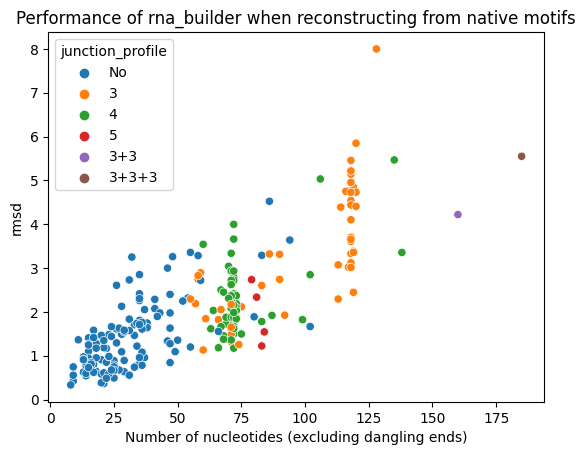

In [88]:
sns.scatterplot(data = singles["from_native"], x = "num_nucs", y="rmsd", hue ="junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of rna_builder when reconstructing from native motifs")

Text(0.5, 1.0, 'Performance of rna_builder when reconstructing from native motifs')

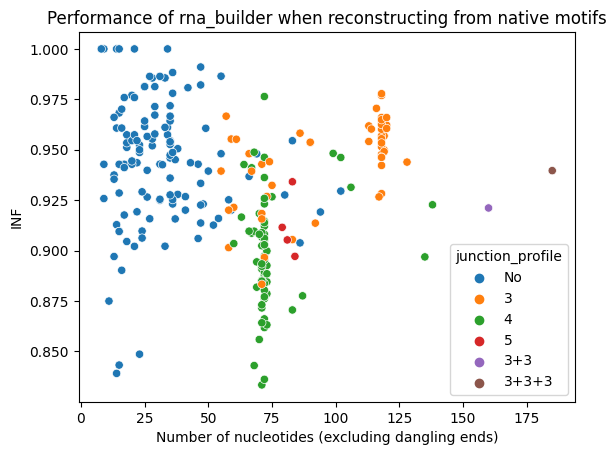

In [89]:
sns.scatterplot(data = singles["from_native"], x = "num_nucs", y="INF_ALL", hue ="junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.ylabel("INF")
plt.title("Performance of rna_builder when reconstructing from native motifs")

Text(0.5, 1.0, 'Performance of rna_builder when reconstructing from native motifs')

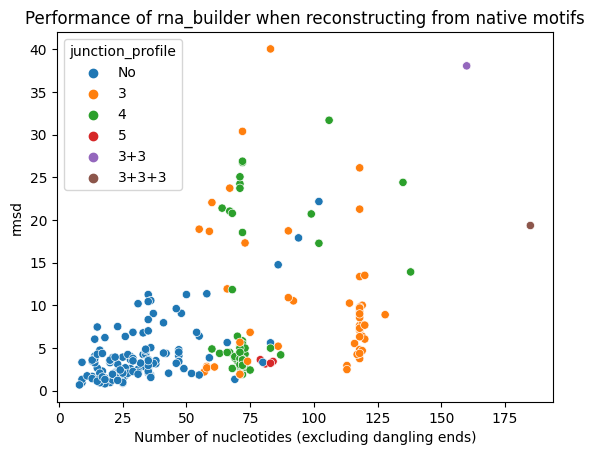

In [90]:
sns.scatterplot(data = singles["loops_top"], x = "num_nucs", y="rmsd", hue ="junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of rna_builder when reconstructing from native motifs")

Text(0.5, 1.0, 'Performance of rna_builder when reconstructing from native motifs')

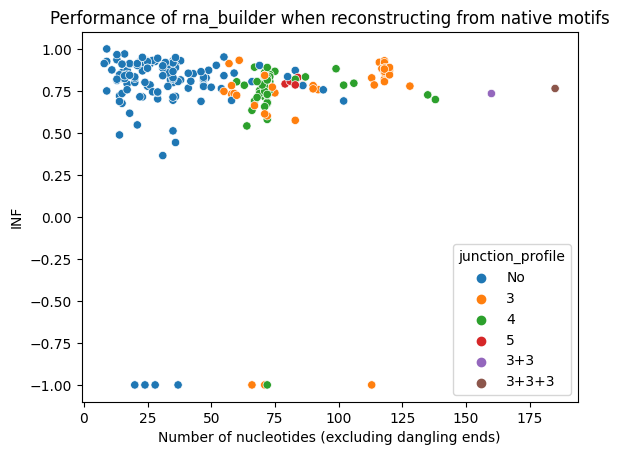

In [91]:
sns.scatterplot(data = singles["loops_top"], x = "num_nucs", y="INF_ALL", hue ="junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.ylabel("INF")
plt.title("Performance of rna_builder when reconstructing from native motifs")

Text(0.5, 1.0, 'asdf')

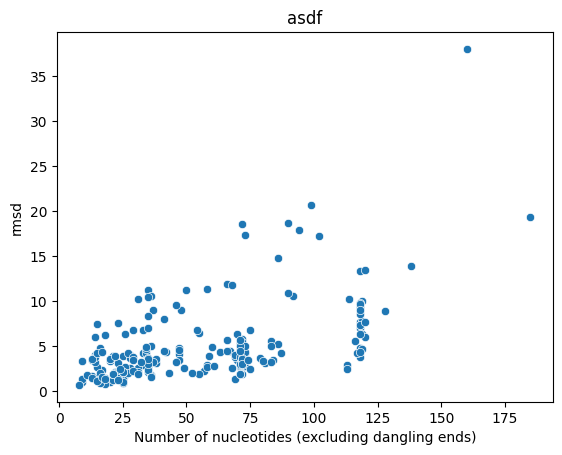

In [92]:
sns.scatterplot(data = singles["loops_top"][singles["loops_top"]["loops_missing"] == False], x = "num_nucs", y="rmsd")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("asdf")

Text(0.5, 1.0, 'Performance of the loops_top method.')

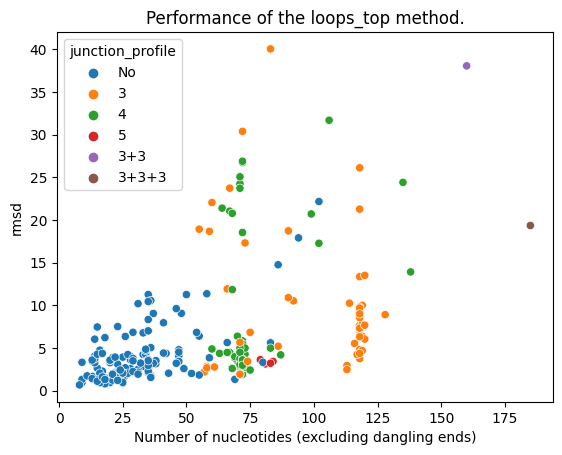

In [93]:
sns.scatterplot(data = singles["loops_top"], x = "num_nucs", y="rmsd", hue = "junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the loops_top method.")

In [94]:
def gnm(df):
    return df.reset_index().groupby(["name", "method"])

def get_method(df, m):
    df = df.reset_index()
    return df[df["method"] == m]
# multis_mean = {}
# for df in multis.items():

def flm(df):
    return df.replace({"loops_missing": {0.:False, 1.:True}})
    
def gnmm(df):
    dfg = gnm(df)
    ret = flm(dfg.mean(numeric_only=True))
    ret["junction_profile"] = dfg.first()["junction_profile"]
    return ret

def gnmmin(df):
    dfg = gnm(df)
    ret = flm(dfg.min(numeric_only=True))
    ret["junction_profile"] = dfg.first()["junction_profile"]
    return ret

Text(0, 0.5, 'Mean RMSD')

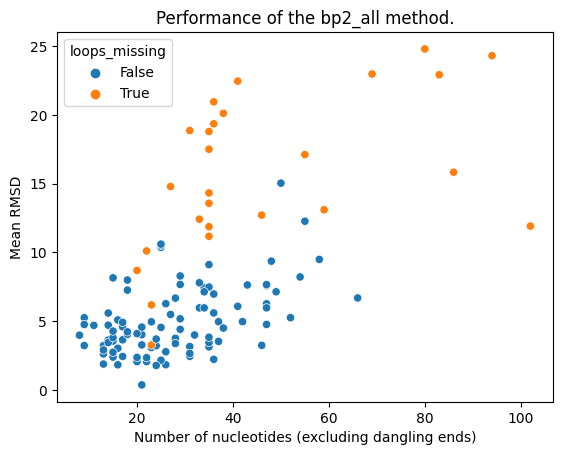

In [95]:
sns.scatterplot(data = gnmm(get_method(data_noj, "bp2_all") ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the bp2_all method.")
plt.ylabel("Mean RMSD")

Text(0, 0.5, 'Mean RMSD')

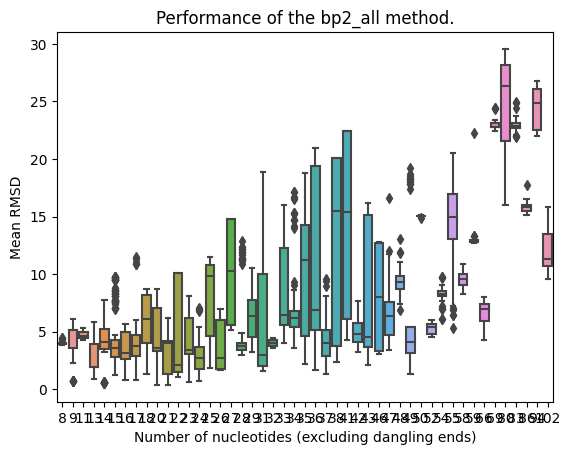

In [96]:
sns.boxplot(data = get_method(data_noj, "bp2_all") , x = "num_nucs", y="rmsd")#, hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the bp2_all method.")
plt.ylabel("Mean RMSD")

/tmp/ipykernel_139310/567312375.py:1: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



Text(0, 0.5, 'Mean RMSD')

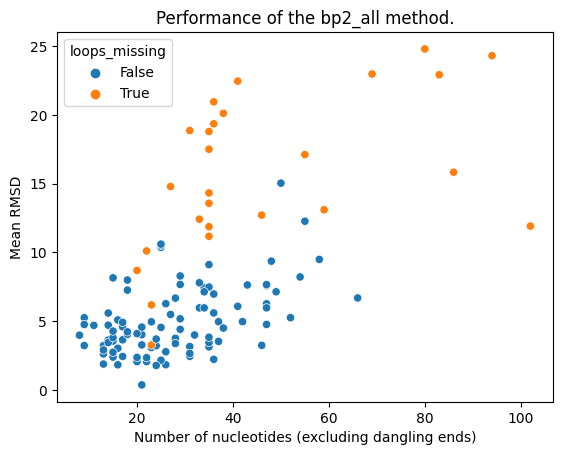

In [97]:
sns.scatterplot(data = flm(gnm(get_method(data_noj, "bp2_all") ).mean().reset_index()), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the bp2_all method.")
plt.ylabel("Mean RMSD")

/tmp/ipykernel_139310/3317788854.py:1: FutureWarning:

Dropping invalid columns in DataFrameGroupBy.min is deprecated. In a future version, a TypeError will be raised. Before calling .min, select only columns which should be valid for the function.



Text(0, 0.5, 'Min RMSD')

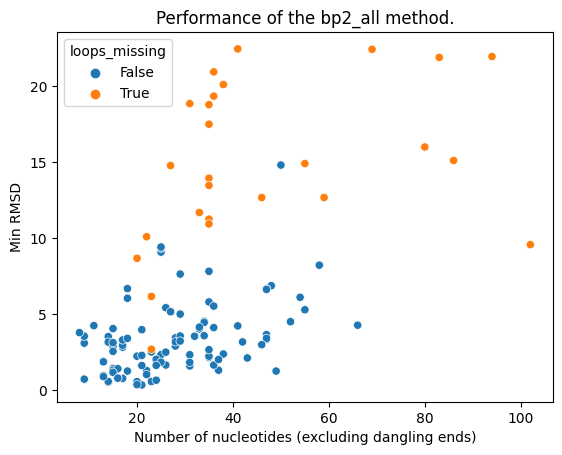

In [98]:
sns.scatterplot(data = flm(gnm(get_method(data_noj, "bp2_all") ).min().reset_index()), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the bp2_all method.")
plt.ylabel("Min RMSD")

/tmp/ipykernel_139310/1199293106.py:1: FutureWarning:

Dropping invalid columns in DataFrameGroupBy.min is deprecated. In a future version, a TypeError will be raised. Before calling .min, select only columns which should be valid for the function.



Text(0, 0.5, 'Min RMSD')

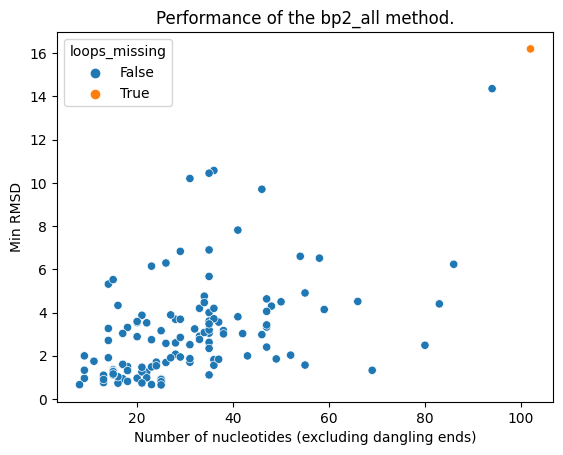

In [99]:
sns.scatterplot(data = flm(gnm(get_method(data_noj, "loops_sample") ).min().reset_index()), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the bp2_all method.")
plt.ylabel("Min RMSD")

/tmp/ipykernel_139310/2515672184.py:1: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



<AxesSubplot: xlabel='variable', ylabel='value'>

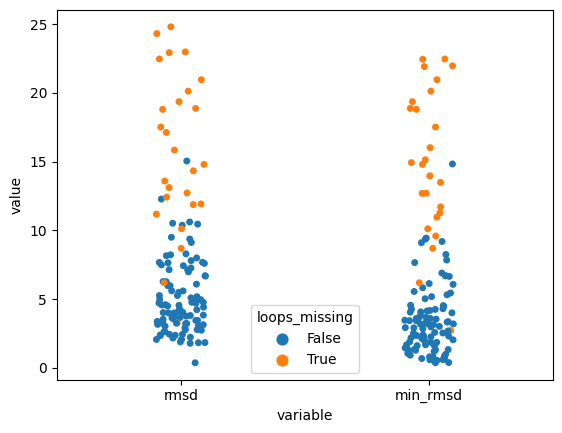

In [100]:
df = gnm(get_method(data_noj, "bp2_all")).mean()

df["min_rmsd"] = gnm(get_method(data_noj, "bp2_all"))["rmsd"]. min()
df = flm(df)

# sns.stripplot(data = gnm(get_method(data_noj, "bp2_all") ).min().reset_index().assign(a=""), y="rmsd", x= "a", hue = "loops_missing")
# plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.title("Performance of the bp2_all method.")
# plt.ylabel("Min RMSD")
mdf = df.reset_index().melt(id_vars=["name", "method", "loops_missing", "num_nucs"], value_vars=["rmsd", "min_rmsd"])
#df

sns.stripplot(data=mdf, x="variable", y="value", hue="loops_missing")


/tmp/ipykernel_139310/2349645697.py:1: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



<AxesSubplot: xlabel='variable', ylabel='value'>

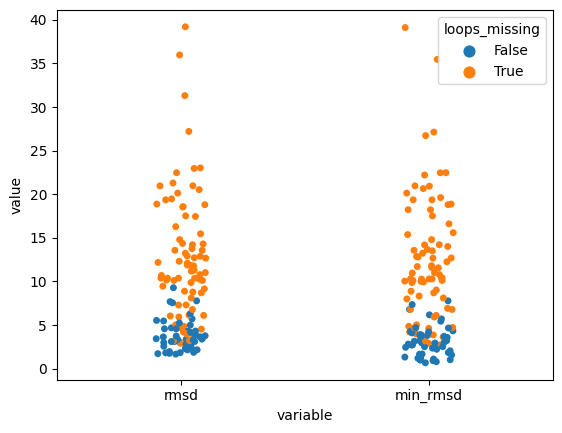

In [101]:
df = gnm(get_method(data_noj, "bp2_reliable")).mean()

df["min_rmsd"] = gnm(get_method(data_noj, "bp2_reliable"))["rmsd"]. min()
df = flm(df)
# sns.stripplot(data = gnm(get_method(data_noj, "bp2_all") ).min().reset_index().assign(a=""), y="rmsd", x= "a", hue = "loops_missing")
# plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.title("Performance of the bp2_all method.")
# plt.ylabel("Min RMSD")
mdf = df.reset_index().melt(id_vars=["name", "method", "loops_missing", "num_nucs"], value_vars=["rmsd", "min_rmsd"])
#df
#sns.reset_orig()
sns.stripplot(data=mdf, x="variable", y="value", hue="loops_missing")


/tmp/ipykernel_139310/1925932568.py:1: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



<AxesSubplot: xlabel='variable', ylabel='value'>

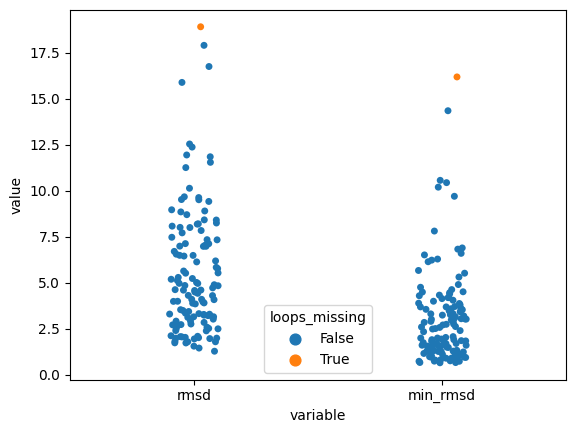

In [102]:
df = gnm(get_method(data_noj, "loops_sample")).mean()

df["min_rmsd"] = gnm(get_method(data_noj, "loops_sample"))["rmsd"]. min()
df = flm(df)
# sns.stripplot(data = gnm(get_method(data_noj, "bp2_all") ).min().reset_index().assign(a=""), y="rmsd", x= "a", hue = "loops_missing")
# plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.title("Performance of the bp2_all method.")
# plt.ylabel("Min RMSD")
mdf = df.reset_index().melt(id_vars=["name", "method", "loops_missing", "num_nucs"], value_vars=["rmsd", "min_rmsd"])
#df
sns.stripplot(data=mdf, x="variable", y="value", hue="loops_missing")


In [103]:
df = gnm(data_noj).mean(numeric_only=True)

df["min_rmsd"] = gnm(data_noj)["rmsd"]. min()
df = flm(df)
df.rename(columns = {"rmsd": "mean_rmsd"}, inplace=True)

# sns.stripplot(data = gnm(get_method(data_noj, "bp2_all") ).min().reset_index().assign(a=""), y="rmsd", x= "a", hue = "loops_missing")
# plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.title("Performance of the bp2_all method.")
# plt.ylabel("Min RMSD")
mdf = df.reset_index().melt(id_vars=["name", "method", "loops_missing", "num_nucs"], value_vars=["mean_rmsd", "min_rmsd"])
#df
"loops_top min_rmsd"

mdf.loc[mdf["variable"] == "mean_rmsd", "variable"] = "mean"
mdf.loc[mdf["variable"] == "min_rmsd", "variable"] = "min"
mdf = mdf[~( (mdf["variable"] == "min") & (mdf["method"] == "loops_top"))]
mdf


,name,method,loops_missing,num_nucs,variable,value
0,NR_4.0_00810.1,bp2_all,False,48.0,mean,9.369710
1,NR_4.0_00810.1,bp2_reliable,False,48.0,mean,9.282523
2,NR_4.0_00810.1,from_native,False,48.0,mean,3.259122
3,NR_4.0_00810.1,loops_sample,False,48.0,mean,7.716808
4,NR_4.0_00810.1,loops_top,False,48.0,mean,9.071343
...,...,...,...,...,...,...
1243,NR_4.0_95874.1,loops_sample,False,24.0,min,1.536729
1245,NR_4.0_99276.1,bp2_all,False,18.0,min,3.427559
1246,NR_4.0_99276.1,bp2_reliable,False,18.0,min,4.214210
1247,NR_4.0_99276.1,from_native,False,18.0,min,1.171440


In [104]:
new_names = mdf ["method"] + "\n" + mdf[ "variable"]
new_names[mdf["method"] == "loops_top"] = "loops_top"
new_names[mdf["method"] == "from_native"] = "from_native"

mdf["new_variable"] = new_names
mdf

,name,method,loops_missing,num_nucs,variable,value,new_variable
0,NR_4.0_00810.1,bp2_all,False,48.0,mean,9.369710,bp2_all\nmean
1,NR_4.0_00810.1,bp2_reliable,False,48.0,mean,9.282523,bp2_reliable\nmean
2,NR_4.0_00810.1,from_native,False,48.0,mean,3.259122,from_native
3,NR_4.0_00810.1,loops_sample,False,48.0,mean,7.716808,loops_sample\nmean
4,NR_4.0_00810.1,loops_top,False,48.0,mean,9.071343,loops_top
...,...,...,...,...,...,...,...
1243,NR_4.0_95874.1,loops_sample,False,24.0,min,1.536729,loops_sample\nmin
1245,NR_4.0_99276.1,bp2_all,False,18.0,min,3.427559,bp2_all\nmin
1246,NR_4.0_99276.1,bp2_reliable,False,18.0,min,4.214210,bp2_reliable\nmin
1247,NR_4.0_99276.1,from_native,False,18.0,min,1.171440,from_native


Text(0, 0.5, 'RMSD')

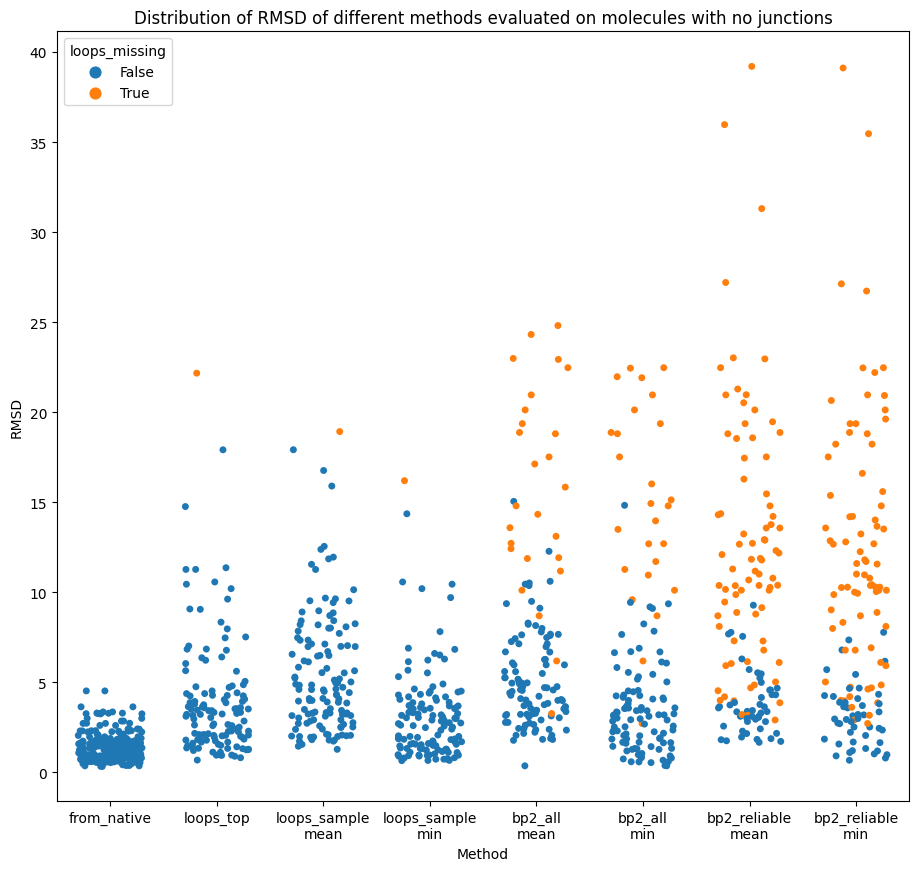

In [105]:
plt.figure(figsize= (11,10))

mdf.replace({"loops_missing": {0.0: False, 1.0: True}}, inplace=True)

#sns.set(rc={"figure.figsize":(8, 4)}) #width=8, height=4
sns.stripplot(data=mdf, x="new_variable", y="value", hue="loops_missing",
             #order = ["force_native])
             #width=400
              order = [
                   'from_native',

                   'loops_top',

                  'loops_sample\nmean',
                   'loops_sample\nmin',

 'bp2_all\nmean',
 'bp2_all\nmin',
                  
 'bp2_reliable\nmean',
 'bp2_reliable\nmin',
              
              ],
              
              jitter=0.3
             )
#df
#new_names
# list(set(new_names))

plt.title("Distribution of RMSD of different methods evaluated on molecules with no junctions")
plt.xlabel("Method")
plt.ylabel("RMSD")


Text(0, 0.5, 'RMSD')

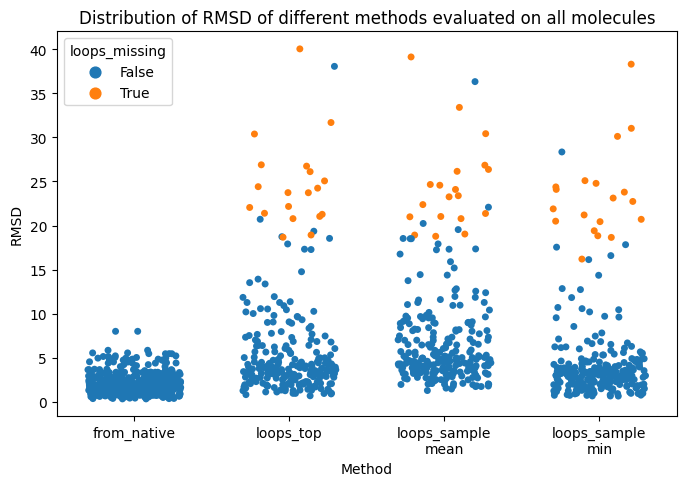

In [106]:
df = gnm(data_j).mean(numeric_only=True)

df["min_rmsd"] = gnm(data_j)["rmsd"]. min()

df.rename(columns = {"rmsd": "mean_rmsd"}, inplace=True)
df = flm(df)
# sns.stripplot(data = gnm(get_method(data_noj, "bp2_all") ).min().reset_index().assign(a=""), y="rmsd", x= "a", hue = "loops_missing")
# plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.title("Performance of the bp2_all method.")
# plt.ylabel("Min RMSD")
mdf = df.reset_index().melt(id_vars=["name", "method", "loops_missing", "num_nucs"], value_vars=["mean_rmsd", "min_rmsd"])
#df
"loops_top min_rmsd"

mdf.loc[mdf["variable"] == "mean_rmsd", "variable"] = "mean"
mdf.loc[mdf["variable"] == "min_rmsd", "variable"] = "min"
mdf = mdf[~( (mdf["variable"] == "min") & (mdf["method"] == "loops_top"))]
mdf


new_names = mdf ["method"] + "\n" + mdf[ "variable"]
new_names[mdf["method"] == "loops_top"] = "loops_top"
new_names[mdf["method"] == "from_native"] = "from_native"

mdf["new_variable"] = new_names
mdf

plt.figure(figsize= (8,5))

#sns.set(rc={"figure.figsize":(8, 4)}) #width=8, height=4
sns.stripplot(data=mdf, x="new_variable", y="value", hue="loops_missing",
             #order = ["force_native])
             #width=400
              order = [
                   'from_native',

                   'loops_top',

                  'loops_sample\nmean',
                   'loops_sample\nmin',

              
              ],
              
              jitter=0.3
             )
#df
#new_names
# list(set(new_names))

plt.title("Distribution of RMSD of different methods evaluated on all molecules")
plt.xlabel("Method")
plt.ylabel("RMSD")


In [107]:
df

num_nucs  num_nucs_with_dangling  num_paired  \
name           method                                                       
NR_4.0_00361.1 from_native      138.0                   142.0        74.0   
               loops_sample     138.0                   142.0        74.0   
               loops_top        138.0                   142.0        74.0   
NR_4.0_00810.1 from_native       48.0                    48.0        38.0   
               loops_sample      48.0                    48.0        38.0   
...                               ...                     ...         ...   
NR_4.0_98802.1 loops_sample     106.0                   107.0        62.0   
               loops_top        106.0                   107.0        62.0   
NR_4.0_99276.1 from_native       18.0                    32.0        10.0   
               loops_sample      18.0                    32.0        10.0   
               loops_top         18.0                    32.0        10.0   

                             num_junctions  has_junctions  num_loops  \
name           method                                                  
NR_4.0_00361.1 from_native             1.0            1.0       10.0   
               loops_sample            1.0            1.0       10.0   
               loops_top               1.0            1.0       10.0   
NR_4.0_00810.1 from_native             0.0            0.0        4.0   
               loops_sample            0.0            0.0        4.0   
...                                    ...            ...        ...   
NR_4.0_98802.1 loops_sample            1.0            1.0        8.0   
               loops_top               1.0            1.0        8.0   
NR_4.0_99276.1 from_native             0.0            0.0        1.0   
               loops_sample            0.0            0.0        1.0   
               loops_top               0.0            0.0        1.0   

                             num_loops_found  mean_rmsd        pvalue  \
name           method                                                   
NR_4.0_00361.1 from_native              10.0   3.354979  0.000000e+00   
               loops_sample             10.0  17.249198  2.295941e-15   
               loops_top                10.0  13.920045  0.000000e+00   
NR_4.0_00810.1 from_native               4.0   3.259122  0.000000e+00   
               loops_sample              4.0   7.716808  3.001500e-04   
...                                      ...        ...           ...   
NR_4.0_98802.1 loops_sample              7.0  33.407145  9.188627e-01   
               loops_top                 7.0  31.690293  7.264063e-01   
NR_4.0_99276.1 from_native               1.0   1.171440  4.366079e-05   
               loops_sample              1.0   3.242205  5.080949e-03   
               loops_top                 1.0   1.316186  6.078252e-05   

                                DI_ALL   INF_ALL    INF_WC   INF_NWC  \
name           method                                                  
NR_4.0_00361.1 from_native    3.635884  0.922741  0.988826  0.670820   
               loops_sample  23.788288  0.725279  0.874639  0.216791   
               loops_top     19.924302  0.698647  0.859338  0.158114   
NR_4.0_00810.1 from_native    3.530586  0.923111  1.000000  1.000000   
               loops_sample   8.863863  0.869294  0.987217  0.280000   
...                                ...       ...       ...       ...   
NR_4.0_98802.1 loops_sample  46.189423  0.724909  0.931323  0.244675   
               loops_top     39.817906  0.795880  0.956183  0.639010   
NR_4.0_99276.1 from_native    1.295076  0.904534  1.000000  1.000000   
               loops_sample   4.997345  0.666189  0.947723 -1.000000   
               loops_top      1.560804  0.843274  1.000000 -1.000000   

                             INF_STACK  loops_missing  multi   min_rmsd  
name           method                                                    
NR_4.0_00361.1 from_native    0.903696          False  

Text(0, 0.5, 'Min RMSD')

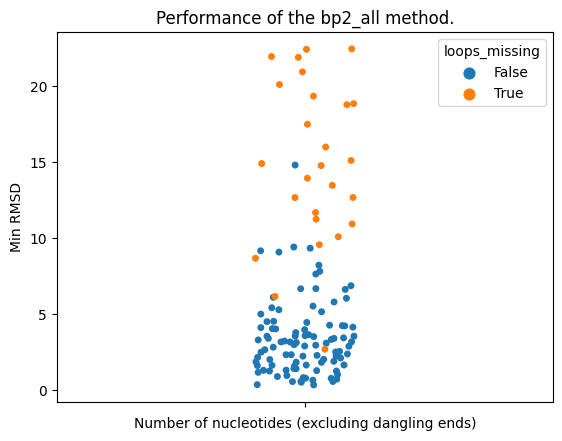

In [108]:




sns.stripplot(data = gnm(get_method(data_noj, "bp2_all") )[["loops_missing", "rmsd"]].min().reset_index().assign(a=""), y="rmsd", x= "a", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the bp2_all method.")
plt.ylabel("Min RMSD")

In [109]:
figsize = (4,3)
ylim = (0,40)

(0.0, 40.0)

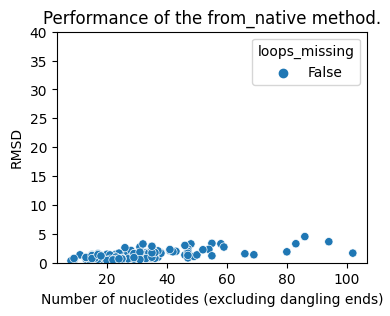

In [110]:
plt.figure(figsize=figsize)
method = "from_native"
sns.scatterplot(data = gnmm(get_method(data_noj, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("RMSD")
plt.ylim(ylim)


Text(0, 0.5, 'Mean RMSD')

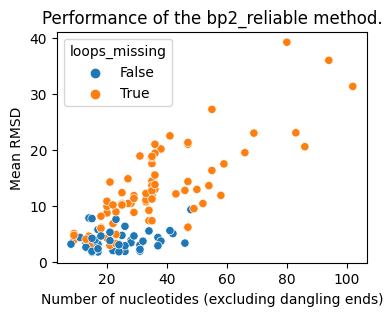

In [111]:
plt.figure(figsize=(4, 3))
method = "bp2_reliable"
sns.scatterplot(data = gnmm(get_method(data_noj, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("Mean RMSD")


(0.0, 40.0)

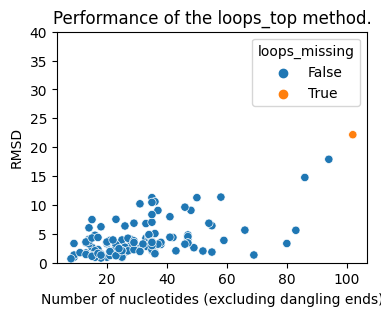

In [112]:
plt.figure(figsize=figsize)
method = "loops_top"
sns.scatterplot(data = gnmm(get_method(data_noj, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("RMSD")
plt.ylim(ylim)


(0.0, 40.0)

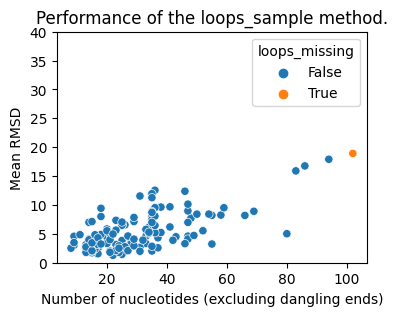

In [113]:
plt.figure(figsize=figsize)
method = "loops_sample"
sns.scatterplot(data = gnmm(get_method(data_noj, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("Mean RMSD")
plt.ylim(ylim)


(0.0, 40.0)

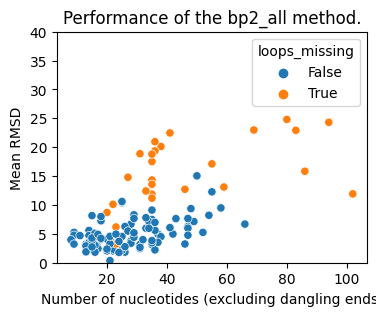

In [114]:
plt.figure(figsize=figsize)
method = "bp2_all"
sns.scatterplot(data = gnmm(get_method(data_noj, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("Mean RMSD")
plt.ylim(ylim)


(0.0, 40.0)

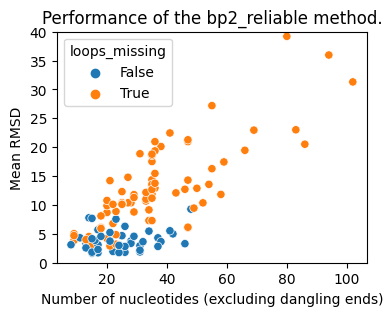

In [115]:
plt.figure(figsize=figsize)
method = "bp2_reliable"
sns.scatterplot(data = gnmm(get_method(data_noj, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("Mean RMSD")
plt.ylim(ylim)


In [116]:
figsize = (4,3)
ylim = None; #(0,40)

(-0.05058465019963854, 8.383479240992969)

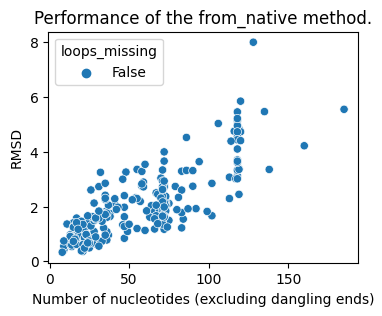

In [117]:
plt.figure(figsize=figsize)
method = "from_native"
sns.scatterplot(data = gnmm(get_method(data_j, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("RMSD")
plt.ylim(ylim)


(-0.05058465019963854, 8.383479240992969)

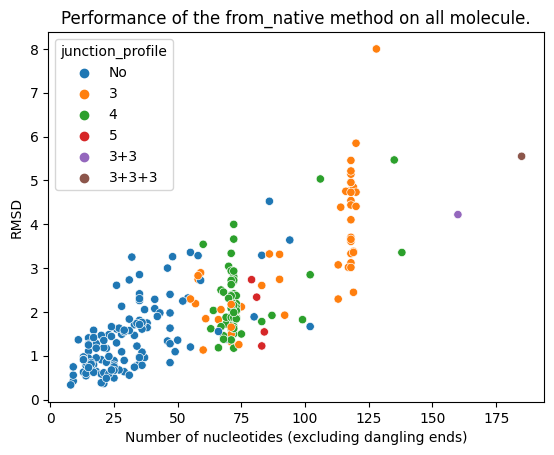

In [118]:
#plt.figure(figsize=figsize)
method = "from_native"
sns.scatterplot(data = gnmm(get_method(data_j, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method on all molecule.")
plt.ylabel("RMSD")
plt.ylim(ylim)


(-1.2852072652617654, 42.01542628034413)

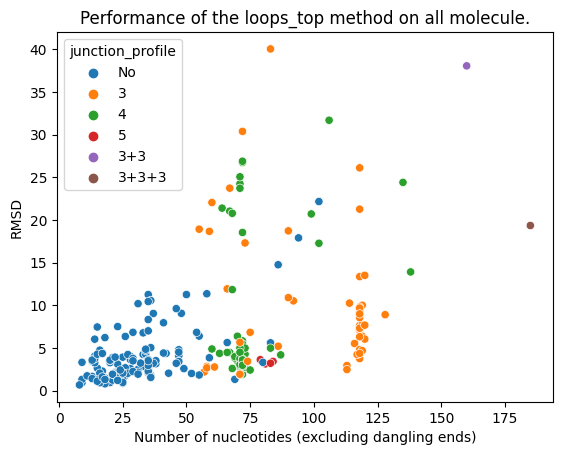

In [119]:
#plt.figure(figsize=figsize)
method = "loops_top"
sns.scatterplot(data = gnmm(get_method(data_j, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method on all molecule.")
plt.ylabel("RMSD")
plt.ylim(ylim)


(-0.6127502148547148, 41.02423874857332)

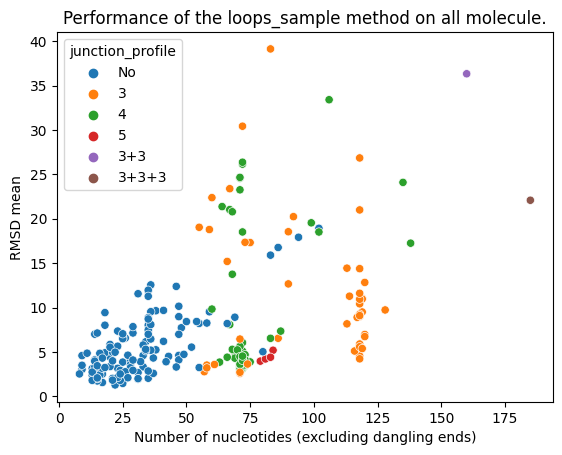

In [120]:
#plt.figure(figsize=figsize)
method = "loops_sample"
sns.scatterplot(data = gnmm(get_method(data_j, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method on all molecule.")
plt.ylabel("RMSD mean")
plt.ylim(ylim)


(-0.6127502148547148, 41.02423874857332)

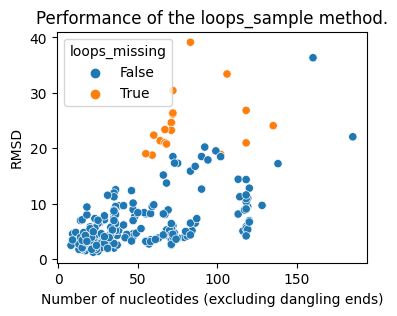

In [121]:
plt.figure(figsize=figsize)
method = "loops_sample"
sns.scatterplot(data = gnmm(get_method(data_j, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("RMSD")
plt.ylim(ylim)


(-0.05058465019963854, 8.383479240992969)

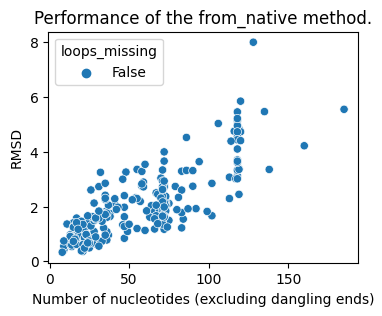

In [122]:
plt.figure(figsize=figsize)
method = "from_native"
sns.scatterplot(data = gnmm(get_method(data_j, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("RMSD")
plt.ylim(ylim)


(-0.05058465019963854, 8.383479240992969)

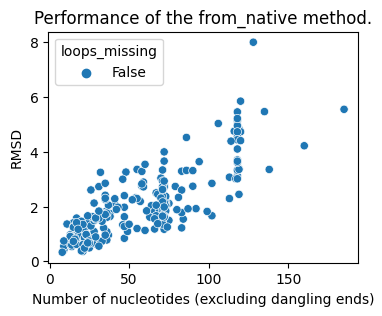

In [123]:
plt.figure(figsize=figsize)
method = "from_native"
sns.scatterplot(data = gnmm(get_method(data_j, method) ).reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title(f"Performance of the {method} method.")
plt.ylabel("RMSD")
plt.ylim(ylim)


/tmp/ipykernel_139310/2983591750.py:2: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



Text(0, 0.5, 'Mean RMSD')

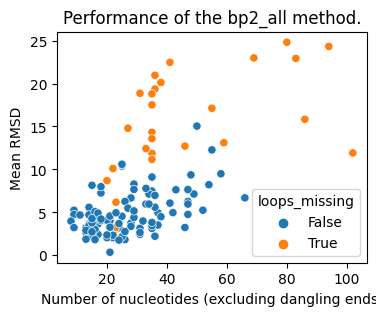

In [124]:
plt.figure(figsize=(4, 3))
sns.scatterplot(data = flm(gnm(get_method(data_noj, "bp2_all") ).mean().reset_index()), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the bp2_all method.")
plt.ylabel("Mean RMSD")


/tmp/ipykernel_139310/4289855176.py:1: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



Text(0.5, 1.0, 'Performance of the bp2_reliable method.')

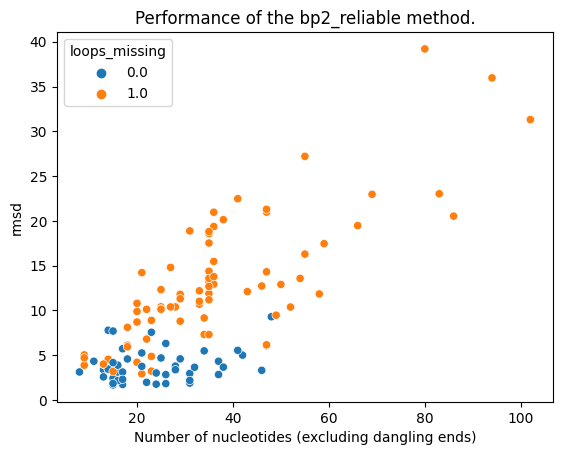

In [125]:
sns.scatterplot(data = gnm(get_method(data_noj, "bp2_reliable") ).mean().reset_index(), x = "num_nucs", y="rmsd", hue = "loops_missing")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of the bp2_reliable method.")

In [126]:
px.scatter(data_frame = singles["loops_top"].reset_index(), x = "num_nucs", y="rmsd", color = "loops_missing", hover_name="name")
# plt.xlabel("Number of nucleotides (excluding dangling ends)")
# plt.title("asdf")

In [127]:
singles["from_native"]

,,pdb_chains,equivalent_nrlist_entries,num_nucs,num_nucs_with_dangling,num_paired,num_junctions,junction_profile,has_junctions,num_loops,num_loops_found,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK,loops_missing
name,instance,,,,,,,,,,,,,,,,,,
NR_4.0_00361.1,1,7LYG|1|A,7LYG|1|A,138,142,74,1,4,True,10,10,3.354979,0.000000e+00,3.635884,0.922741,0.988826,0.670820,0.903696,False
NR_4.0_00810.1,1,4C7O|1|E,4C7O|1|E,48,48,38,0,No,False,4,4,3.259122,0.000000e+00,3.530586,0.923111,1.000000,1.000000,0.880078,False
NR_4.0_01147.1,1,6GZ4|1|Bw,6GZ4|1|Bw,72,76,40,1,4,True,5,5,1.596263,0.000000e+00,1.797885,0.887856,0.977008,0.516398,0.880391,False
NR_4.0_01689.1,1,6KYV|1|G,"6KYV|1|G,6KYV|1|C,6KYV|1|E,6KYV|1|A,6KYV|1|K,6...",22,22,18,0,No,False,1,1,1.166121,4.247957e-07,1.235868,0.943564,1.000000,1.000000,0.909509,False
NR_4.0_01806.1,1,3IAB|1|R,3IAB|1|R,46,46,24,0,No,False,2,2,1.334821,0.000000e+00,1.415719,0.942857,1.000000,-1.000000,0.913043,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NR_4.0_96274.1,1,6T4Q|1|7,"6T4Q|1|7,6Q8Y|1|m,6T7I|1|7",71,75,34,1,3,True,3,3,1.650925,0.000000e+00,1.802863,0.915724,0.974679,0.857143,0.902698,False
NR_4.0_97773.1,1,6YDP|1|AV,"6YDP|1|AV,7NQL|1|AV,7NQH|1|AV",67,71,30,1,3,True,4,4,2.051232,0.000000e+00,2.183570,0.939394,1.000000,0.500000,0.928571,False
NR_4.0_98593.1,1,5D8H|1|A,5D8H|1|A,74,74,32,1,3,True,5,5,1.252860,0.000000e+00,1.327057,0.944089,0.974679,0.894427,0.941858,False


In [128]:
#NR_4.0_37229.2 (1MFQ|1|A)

Text(0.5, 1.0, 'Distribution of RMSD when reconstructing from native motifs')

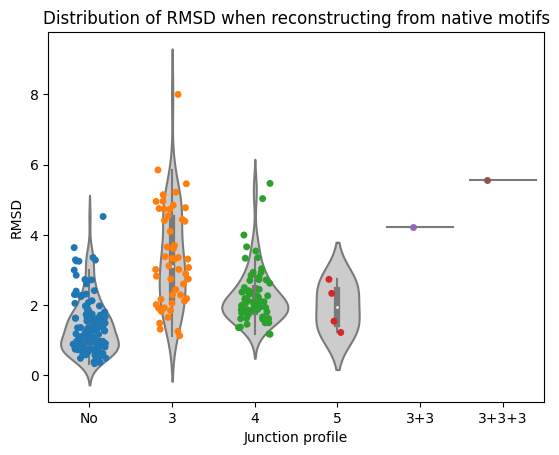

In [129]:
sns.violinplot(data = singles["from_native"], y="rmsd", x="junction_profile", color="0.8")
sns.stripplot(jitter=0.2, data = singles["from_native"], y="rmsd", x="junction_profile")#, hue ="junction_profile")
plt.xlabel("Junction profile")
plt.ylabel("RMSD")
plt.title("Distribution of RMSD when reconstructing from native motifs")

Text(0.5, 1.0, 'Distribution of INF when reconstructing from native motifs')

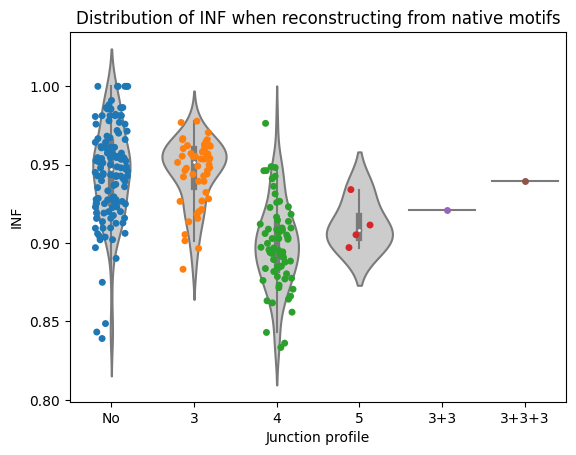

In [130]:
sns.violinplot(data = singles["from_native"], y="INF_ALL", x="junction_profile", color="0.8")
sns.stripplot(jitter=0.2, data = singles["from_native"], y="INF_ALL", x="junction_profile")#, hue ="junction_profile")
plt.xlabel("Junction profile")
plt.ylabel("INF")
plt.title("Distribution of INF when reconstructing from native motifs")



Text(0.5, 1.0, 'Performance of rna_builder when reconstructing from native motifs')

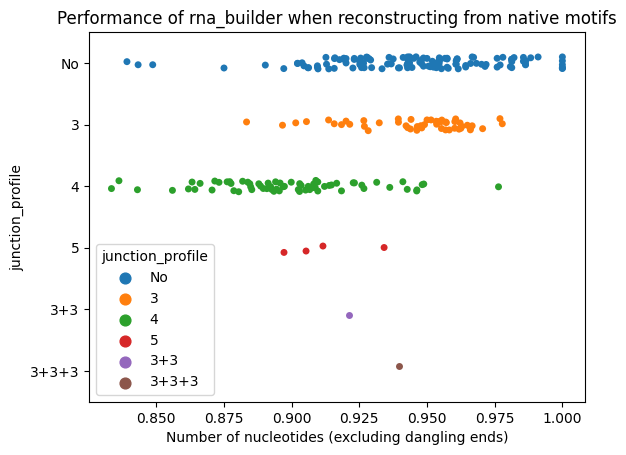

In [131]:
sns.stripplot(data = singles["from_native"], x="INF_ALL", y="junction_profile", hue ="junction_profile")
plt.xlabel("Number of nucleotides (excluding dangling ends)")
plt.title("Performance of rna_builder when reconstructing from native motifs")

In [132]:
df = pd.DataFrame()


In [133]:
def create_table_(metric, best_is_min):
    df = pd.DataFrame(index = info.index, columns = pd.MultiIndex.from_tuples([], names=["", ""]))
    df[ "", "pdb_chains"] = info["pdb_chains"]

    df[ "", "num_nucs"] = info["num_nucs"]

    for (k,v) in singles.items():
        df[k, "."] = v.reset_index().set_index(["name"])[metric]
    for (k,v) in multis.items():
        if best_is_min:
            df[k, "best"] = v[metric].groupby("name").min()
        else:
            df[k, "best"] = v[metric].groupby("name").max()

        df[k, "mean"] = v[metric].groupby("name").mean()
        df[k, "variance"] = v[metric].groupby("name").var()
    df.sort_values(by=[("","num_nucs")], inplace=True)
    # Remove rows that have all NaN's
    values = list(set(df.columns) - {("", "pdb_chains"), ("", "num_nucs")})
    df.drop(df[df[values].isna().all(axis=1)].index, inplace=True)
    
    df.style.set_caption("asdfads")

    return df

df=create_table("rmsd", best_is_min=True)
#df.melt(id_vars = [")
df

# def make_pretty(styler):
#     styler.set_caption("RMSD")
#     return styler

# df = create_table("INF_ALL", best_is_min=False)
# df.style

from_native  loops_top loops_sample  \
                pdb_chains num_nucs           .          .         best   
name                                                                      
NR_4.0_53827.1    1ZDJ|1|R        8    0.332782   0.683003     0.662086   
NR_4.0_11942.1    6MSF|1|S        9    0.555300   1.330012     1.330012   
NR_4.0_88374.1    4C9D|1|D        9    0.744389   3.332600     1.996021   
NR_4.0_08043.1  6Z6B|1|UUU        9    0.421026   0.956092     0.956092   
NR_4.0_41594.1    4ILM|1|C       11    1.362498   1.747158     1.747158   
...                    ...      ...         ...        ...          ...   
NR_4.0_37229.2    1MFQ|1|A      128    8.000113   8.912166     6.239069   
NR_4.0_38802.1    7LYF|1|A      135    5.466631  24.411109    20.442761   
NR_4.0_00361.1    7LYG|1|A      138    3.354979  13.920045     8.550871   
NR_4.0_47162.1    3PDR|1|X      160    4.219896  38.064133    28.351475   
NR_4.0_33922.2    4R4V|1|A      185    5.550300  19.359630    12.848565   

                                     bp2_reliable                      \
                     mean   variance         best      mean  variance   
name                                                                    
NR_4.0_53827.1   2.520760   3.180851     2.740663  3.113805  0.053499   
NR_4.0_11942.1   3.023551   0.541316     3.866230  3.866230  0.000000   
NR_4.0_88374.1   3.493260   0.373221     4.695086  4.695086  0.000000   
NR_4.0_08043.1   4.581878   1.657999     5.021431  5.021431  0.000000   
NR_4.0_41594.1   4.854649   1.104059     4.264324  4.314152  0.002339   
...                   ...        ...          ...       ...       ...   
NR_4.0_37229.2   9.725047   4.938962          NaN       NaN       NaN   
NR_4.0_38802.1  24.096514   5.389499          NaN       NaN       NaN   
NR_4.0_00361.1  17.249198  11.802651          NaN       NaN       NaN   
NR_4.0_47162.1  36.333011   8.259618          NaN       NaN       NaN   
NR_4.0_33922.2  22.084936  21.096294          NaN       NaN       NaN   

                 bp2_all                      
                    best      mean  variance  
name                                          
NR_4.0_53827.1  3.805773  3.983205  0.021122  
NR_4.0_11942.1  3.570631  4.759634  0.456131  
NR_4.0_88374.1  0.744389  3.229081  2.200882  
NR_4.0_08043.1  3.112043  5.254823  0.357326  
NR_4.0_41594.1  4.264324  4.696399  0.123472  
...                  ...       ...       ...  
NR_4.0_37229.2       NaN       NaN       NaN  
NR_4.0_38802.1       NaN       NaN       NaN  
NR_4.0_00361.1       NaN       NaN       NaN  
NR_4.0_47162.1       NaN       NaN       NaN  
NR_4.0_33922.2       NaN       NaN       NaN  

[249 rows x 13 columns]

In [134]:
# with pd.ExcelWriter('output.xlsx') as writer:  
#     df=create_table("rmsd", best_is_min=True)
#     df.to_excel(writer, sheet_name='RMSD')
    
#     df=create_table("INF_ALL", best_is_min=False)
#     df.to_excel(writer, sheet_name='INF')
    
#     df=create_table("DI_ALL", best_is_min=True)
#     df.to_excel(writer, sheet_name='DI')


In [135]:
molecule = "NR_4.0_33922.2"

In [136]:
chains = info.loc[molecule]["pdb_chains"]
df = data_j.loc[[molecule]]


In [137]:
f"{molecule} ({chains})"

'NR_4.0_33922.2 (4R4V|1|A)'

Text(0.5, 1.0, 'Distribution of NR_4.0_33922.2 (4R4V|1|A) prediction RMSD')

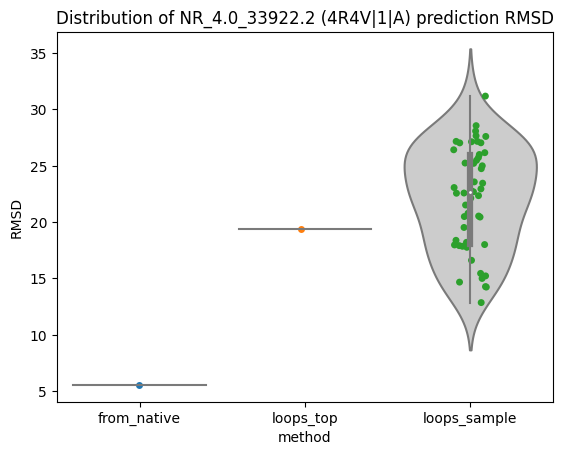

In [138]:

from matplotlib.collections import PathCollection
ax = sns.violinplot( data = df.reset_index(),  x = "method", y = "rmsd", color=".8")
for artist in ax.lines:
    artist.set_zorder(10)
for artist in ax.findobj(PathCollection):
    artist.set_zorder(11)
sns.stripplot( data = df.reset_index(),  x = "method", y = "rmsd")
plt.ylabel("RMSD")
plt.title(f"Distribution of {molecule} ({chains}) prediction RMSD")

In [139]:
# find molecule with lowest RMSD
df.loc[df.groupby(["name", "method"])["rmsd"].idxmin()]

pdb_chains   equivalent_nrlist_entries  \
name           method       instance                                          
NR_4.0_33922.2 from_native  1          4R4V|1|A  4R4V|1|A,5V3I|1|A,4R4P|1|A   
               loops_sample 8          4R4V|1|A  4R4V|1|A,5V3I|1|A,4R4P|1|A   
               loops_top    1          4R4V|1|A  4R4V|1|A,5V3I|1|A,4R4P|1|A   

                                      num_nucs  num_nucs_with_dangling  \
name           method       instance                                     
NR_4.0_33922.2 from_native  1              185                     185   
               loops_sample 8              185                     185   
               loops_top    1              185                     185   

                                      num_paired  num_junctions  \
name           method       instance                              
NR_4.0_33922.2 from_native  1                122              3   
               loops_sample 8                122              3   
               loops_top    1                122              3   

                                     junction_profile  has_junctions  \
name           method       instance                                   
NR_4.0_33922.2 from_native  1                   3+3+3           True   
               loops_sample 8                   3+3+3           True   
               loops_top    1                   3+3+3           True   

                                      num_loops  num_loops_found       rmsd  \
name           method       instance                                          
NR_4.0_33922.2 from_native  1              13.0               13   5.550300   
               loops_sample 8              13.0               13  12.848565   
               loops_top    1              13.0               13  19.359630   

                                      pvalue     DI_ALL   INF_ALL    INF_WC  \
name           method       instance                                          
NR_4.0_33922.2 from_native  1            0.0   5.906686  0.939664  1.000000   
               loops_sample 8            0.0  16.964502  0.757379  0.930484   
               loops_top    1            0.0  25.319842  0.764603  0.953463   

                                       INF_NWC  INF_STACK  loops_missing  \
name           method       instance                                       
NR_4.0_33922.2 from_native  1         0.762770   0.926050          False   
               loops_sample 8         0.000000   0.727970          False   
               loops_top    1         0.119523   0.722108          False   

                                      multi  
name           method       instance         
NR_4.0_33922.2 from_native  1         False  
               loops_sample 8          True  
               loops_top    1         False

In [140]:
molecule = "NR_4.0_02963.1"

In [141]:
chains = info.loc[molecule]["pdb_chains"]
df = data_noj.loc[[molecule]]


In [142]:
f"{molecule} ({chains})"

'NR_4.0_02963.1 (5DEA|1|C)'

Text(0.5, 1.0, 'Distribution of NR_4.0_02963.1 (5DEA|1|C) prediction RMSD')

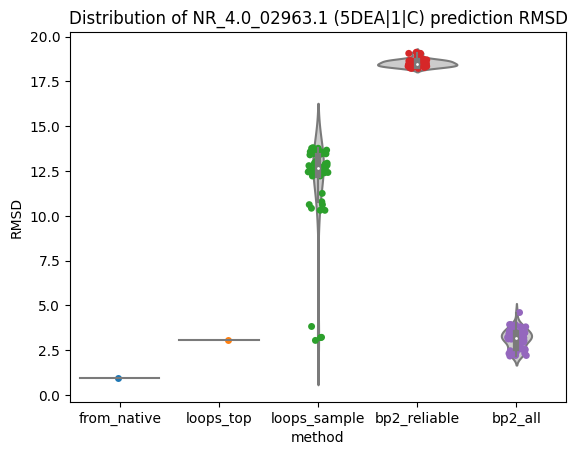

In [143]:

from matplotlib.collections import PathCollection
ax = sns.violinplot( data = df.reset_index(),  x = "method", y = "rmsd", color=".8")
for artist in ax.lines:
    artist.set_zorder(10)
for artist in ax.findobj(PathCollection):
    artist.set_zorder(11)
sns.stripplot( data = df.reset_index(),  x = "method", y = "rmsd")
plt.ylabel("RMSD")
plt.title(f"Distribution of {molecule} ({chains}) prediction RMSD")

In [144]:
# find molecule with lowest RMSD
df.loc[df.groupby(["name", "method"])["rmsd"].idxmin()]

pdb_chains   equivalent_nrlist_entries  \
name           method       instance                                          
NR_4.0_02963.1 bp2_all      out_0_35   5DEA|1|C  5DEA|1|C,5DE5|1|C,5DE8|1|C   
               bp2_reliable out_0_28   5DEA|1|C  5DEA|1|C,5DE5|1|C,5DE8|1|C   
               from_native  1          5DEA|1|C  5DEA|1|C,5DE5|1|C,5DE8|1|C   
               loops_sample 49         5DEA|1|C  5DEA|1|C,5DE5|1|C,5DE8|1|C   
               loops_top    1          5DEA|1|C  5DEA|1|C,5DE5|1|C,5DE8|1|C   

                                      num_nucs  num_nucs_with_dangling  \
name           method       instance                                     
NR_4.0_02963.1 bp2_all      out_0_35        35                      35   
               bp2_reliable out_0_28        35                      35   
               from_native  1               35                      35   
               loops_sample 49              35                      35   
               loops_top    1               35                      35   

                                      num_paired  num_junctions  \
name           method       instance                              
NR_4.0_02963.1 bp2_all      out_0_35          14              0   
               bp2_reliable out_0_28          14              0   
               from_native  1                 14              0   
               loops_sample 49                14              0   
               loops_top    1                 14              0   

                                     junction_profile  has_junctions  \
name           method       instance                                   
NR_4.0_02963.1 bp2_all      out_0_35               No          False   
               bp2_reliable out_0_28               No          False   
               from_native  1                      No          False   
               loops_sample 49                     No          False   
               loops_top    1                      No          False   

                                      num_loops  num_loops_found       rmsd  \
name           method       instance                                          
NR_4.0_02963.1 bp2_all      out_0_35        2.0                2   2.174124   
               bp2_reliable out_0_28        2.0                1  18.224532   
               from_native  1               2.0                2   0.970361   
               loops_sample 49              2.0                2   3.046749   
               loops_top    1               2.0                2   3.046749   

                                            pvalue     DI_ALL   INF_ALL  \
name           method       instance                                      
NR_4.0_02963.1 bp2_all      out_0_35  1.179778e-12   2.396463  0.907222   
               bp2_reliable out_0_28  9.716425e-01  34.897322  0.522233   
               from_native  1         7.938095e-15   1.016569  0.954545   
               loops_sample 49        3.363965e-11   3.277392  0.929626   
               loops_top    1         3.363965e-11   3.277392  0.929626   

                                      INF_WC   INF_NWC  INF_STACK  \
name           method       instance                                
NR_4.0_02963.1 bp2_all      out_0_35     1.0  0.925820   0.869565   
               bp2_reliable out_0_28     1.0  0.000000   0.636146   
               from_native  1            1.0  0.963624   0.936382   
               loops_sample 49           1.0  0.886405   0.933564   
               loops_top    1            1.0  0.886405   0.933564   

                                      loops_missing  multi  
name           method       instance                        
NR_4.0_02963.1 bp2_all      out_0_35          False   True  
               bp2_reliable out_0_28           True   True  
               from_native  1                 False  False  
               loops_sample 49                False   True  
               loops_top    1                 False  False

In [242]:
df = data_noj.reset_index()
ix = df[(df["method"] == "bp2_reliable") & (df["loops_missing"] == False)].groupby(["name"]).first().index

In [243]:
" ".join(a+".rass" for a in ix)

'NR_4.0_00810.1.rass NR_4.0_01689.1.rass NR_4.0_02491.1.rass NR_4.0_02858.1.rass NR_4.0_04166.1.rass NR_4.0_06402.1.rass NR_4.0_10362.1.rass NR_4.0_12063.1.rass NR_4.0_14903.1.rass NR_4.0_14947.1.rass NR_4.0_14959.1.rass NR_4.0_15508.1.rass NR_4.0_17333.1.rass NR_4.0_18718.1.rass NR_4.0_18914.1.rass NR_4.0_23423.1.rass NR_4.0_23975.1.rass NR_4.0_27657.1.rass NR_4.0_39792.1.rass NR_4.0_40560.1.rass NR_4.0_41594.1.rass NR_4.0_44743.1.rass NR_4.0_49782.1.rass NR_4.0_52425.2.rass NR_4.0_53827.1.rass NR_4.0_56838.1.rass NR_4.0_60411.1.rass NR_4.0_65533.1.rass NR_4.0_65600.1.rass NR_4.0_66108.1.rass NR_4.0_66328.1.rass NR_4.0_67726.2.rass NR_4.0_69759.1.rass NR_4.0_70662.1.rass NR_4.0_72335.1.rass NR_4.0_72481.1.rass NR_4.0_74379.1.rass NR_4.0_75028.1.rass NR_4.0_75875.1.rass NR_4.0_80987.1.rass NR_4.0_81641.1.rass NR_4.0_89230.1.rass NR_4.0_91105.1.rass NR_4.0_92029.1.rass NR_4.0_95596.1.rass NR_4.0_95874.1.rass NR_4.0_99276.1.rass'

In [244]:
len(ix)

47

In [245]:
molecule="NR_4.0_00810.1"

In [246]:
molecule="NR_4.0_18718.1"

In [247]:
molecule="NR_4.0_56838.1"

In [248]:
#molecule="NR_4.0_66328.1"

In [249]:
chains = info.loc[molecule]["pdb_chains"]
df = data_noj.loc[[molecule]]


In [250]:
f"{molecule} ({chains})"

'NR_4.0_56838.1 (8D29|1|F)'

In [251]:
from rna_bits.utils.data_path import DATA_PATH
def get_file_path(s: str) -> str:
    path = os.path.join(DATA_PATH, s)
    return path

p = get_file_path("benchmark/auto_from_pdb/all/provided_ss/"+molecule+".rass")
with open(p) as f:
    print(f.read())

GGCGAUACCAGCGAAACACGCCCUUGGCAGCGUC
((((...((((((.....)))...)))...))))
native: NR_4.0_56838.1



In [252]:
prev_df = df

Text(0.5, 1.0, 'Distribution of NR_4.0_56838.1 (8D29|1|F) prediction RMSD')

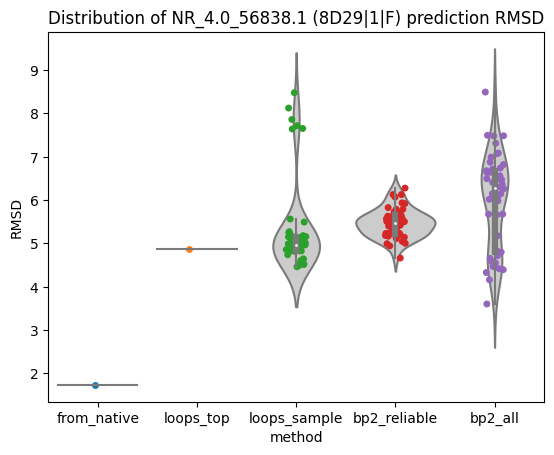

In [253]:

from matplotlib.collections import PathCollection
ax = sns.violinplot( data = df.reset_index(),  x = "method", y = "rmsd", color=".8")
for artist in ax.lines:
    artist.set_zorder(10)
for artist in ax.findobj(PathCollection):
    artist.set_zorder(11)
sns.stripplot( data = df.reset_index(),  x = "method", y = "rmsd")
plt.ylabel("RMSD")
plt.title(f"Distribution of {molecule} ({chains}) prediction RMSD")

In [254]:
# find molecule with lowest RMSD
df.loc[df.groupby(["name", "method"])["rmsd"].idxmin()]

pdb_chains equivalent_nrlist_entries  \
name           method       instance                                        
NR_4.0_56838.1 bp2_all      out_0_39   8D29|1|F                  8D29|1|F   
               bp2_reliable out_0_11   8D29|1|F                  8D29|1|F   
               from_native  1          8D29|1|F                  8D29|1|F   
               loops_sample 11         8D29|1|F                  8D29|1|F   
               loops_top    1          8D29|1|F                  8D29|1|F   

                                      num_nucs  num_nucs_with_dangling  \
name           method       instance                                     
NR_4.0_56838.1 bp2_all      out_0_39        34                      34   
               bp2_reliable out_0_11        34                      34   
               from_native  1               34                      34   
               loops_sample 11              34                      34   
               loops_top    1               34                      34   

                                      num_paired  num_junctions  \
name           method       instance                              
NR_4.0_56838.1 bp2_all      out_0_39          20              0   
               bp2_reliable out_0_11          20              0   
               from_native  1                 20              0   
               loops_sample 11                20              0   
               loops_top    1                 20              0   

                                     junction_profile  has_junctions  \
name           method       instance                                   
NR_4.0_56838.1 bp2_all      out_0_39               No          False   
               bp2_reliable out_0_11               No          False   
               from_native  1                      No          False   
               loops_sample 11                     No          False   
               loops_top    1                      No          False   

                                      num_loops  num_loops_found      rmsd  \
name           method       instance                                         
NR_4.0_56838.1 bp2_all      out_0_39        3.0                3  3.602607   
               bp2_reliable out_0_11        3.0                3  4.662961   
               from_native  1               3.0                3  1.737515   
               loops_sample 11              3.0                3  4.461801   
               loops_top    1               3.0                3  4.868570   

                                            pvalue    DI_ALL   INF_ALL  \
name           method       instance                                     
NR_4.0_56838.1 bp2_all      out_0_39  7.834459e-10  4.252500  0.847174   
               bp2_reliable out_0_11  2.543535e-08  6.313679  0.738549   
               from_native  1         7.554513e-13  1.814775  0.957427   
               loops_sample 11        1.348908e-08  5.096796  0.875413   
               loops_top    1         4.803290e-08  5.426707  0.897150   

                                        INF_WC   INF_NWC  INF_STACK  \
name           method       instance                                  
NR_4.0_56838.1 bp2_all      out_0_39  0.818182  0.707107   0.872872   
               bp2_reliable out_0_11  0.904534  0.000000   0.697863   
               from_native  1         1.000000  1.000000   0.935414   
               loops_sample 11        0.957427  0.500000   0.883960   
               loops_top    1         0.957427  0.577350   0.898717   

                                      loops_missing  multi  
name           method       instance                        
NR_4.0_56838.1 bp2_all      out_0_39          False   True  
               bp2_reliable out_0_11          False   True  
               from_native  1                 False  False  
               loops_sample 11                False   True  
               loops_top    1                 False  False

In [286]:
#extra_dir = get_path("experiments/8D29_insert_loops/measures/")


In [287]:
DIR = ("experiments/8D29_insert_loops/measures/")
df = collect_multi(DIR)
df=df.reset_index()
df

,name,instance,rmsd,pvalue,DI_ALL,INF_ALL,INF_WC,INF_NWC,INF_STACK,DIR,REAL_DIR
0,loops_sample_10,1,4.942829,6.024269e-08,6.060427,0.815591,0.953463,0.447214,0.813125,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...
1,loops_sample_10,10,5.183314,1.240335e-07,6.108906,0.848485,0.909091,0.707107,0.829515,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...
2,loops_sample_10,11,4.861771,4.704321e-08,5.484818,0.886405,0.957427,0.500000,0.898717,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...
3,loops_sample_10,12,4.861771,4.704321e-08,5.484818,0.886405,0.957427,0.500000,0.898717,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...
4,loops_sample_10,13,7.896911,1.303052e-04,10.580682,0.746352,0.953463,0.500000,0.683130,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...
...,...,...,...,...,...,...,...,...,...,...,...
195,loops_sample_50,50,5.951703,1.110102e-06,8.106188,0.734217,0.870388,0.000000,0.698297,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...
196,loops_sample_50,6,5.575259,3.878028e-07,6.581010,0.847174,0.953463,0.500000,0.846327,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...
197,loops_sample_50,7,6.830855,1.098564e-05,9.672858,0.706188,0.953463,0.000000,0.637022,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...
198,loops_sample_50,8,4.696582,2.824632e-08,5.543824,0.847174,0.953463,0.577350,0.829228,experiments/8D29_insert_loops/measures/,/home/paul/Masters/RNA/data/experiments/8D29_i...


In [288]:
df = df.drop(columns=["DIR", "REAL_DIR"])
df["method"] = df["name"]
df["name"] = molecule

In [289]:


df = df.set_index(["name", "method", "instance"])
df

rmsd        pvalue     DI_ALL  \
name           method          instance                                      
NR_4.0_56838.1 loops_sample_10 1         4.942829  6.024269e-08   6.060427   
                               10        5.183314  1.240335e-07   6.108906   
                               11        4.861771  4.704321e-08   5.484818   
                               12        4.861771  4.704321e-08   5.484818   
                               13        7.896911  1.303052e-04  10.580682   
...                                           ...           ...        ...   
               loops_sample_50 50        5.951703  1.110102e-06   8.106188   
                               6         5.575259  3.878028e-07   6.581010   
                               7         6.830855  1.098564e-05   9.672858   
                               8         4.696582  2.824632e-08   5.543824   
                               9         3.257005  2.342218e-10   4.133891   

                                          INF_ALL    INF_WC   INF_NWC  \
name           method          instance                                 
NR_4.0_56838.1 loops_sample_10 1         0.815591  0.953463  0.447214   
                               10        0.848485  0.909091  0.707107   
                               11        0.886405  0.957427  0.500000   
                               12        0.886405  0.957427  0.500000   
                               13        0.746352  0.953463  0.500000   
...                                           ...       ...       ...   
               loops_sample_50 50        0.734217  0.870388  0.000000   
                               6         0.847174  0.953463  0.500000   
                               7         0.706188  0.953463  0.000000   
                               8         0.847174  0.953463  0.577350   
                               9         0.787879  0.904534  0.707107   

                                         INF_STACK  
name           method          instance             
NR_4.0_56838.1 loops_sample_10 1          0.813125  
                               10         0.829515  
                               11         0.898717  
                               12         0.898717  
                               13         0.683130  
...                                            ...  
               loops_sample_50 50         0.698297  
                               6          0.846327  
                               7          0.637022  
                               8          0.829228  
                               9          0.744387  

[200 rows x 7 columns]

In [290]:
prev_df

pdb_chains equivalent_nrlist_entries  \
name           method       instance                                        
NR_4.0_56838.1 from_native  1          8D29|1|F                  8D29|1|F   
               loops_top    1          8D29|1|F                  8D29|1|F   
               loops_sample 1          8D29|1|F                  8D29|1|F   
                            10         8D29|1|F                  8D29|1|F   
                            11         8D29|1|F                  8D29|1|F   
...                                         ...                       ...   
               bp2_all      out_0_5    8D29|1|F                  8D29|1|F   
                            out_0_6    8D29|1|F                  8D29|1|F   
                            out_0_7    8D29|1|F                  8D29|1|F   
                            out_0_8    8D29|1|F                  8D29|1|F   
                            out_0_9    8D29|1|F                  8D29|1|F   

                                      num_nucs  num_nucs_with_dangling  \
name           method       instance                                     
NR_4.0_56838.1 from_native  1               34                      34   
               loops_top    1               34                      34   
               loops_sample 1               34                      34   
                            10              34                      34   
                            11              34                      34   
...                                        ...                     ...   
               bp2_all      out_0_5         34                      34   
                            out_0_6         34                      34   
                            out_0_7         34                      34   
                            out_0_8         34                      34   
                            out_0_9         34                      34   

                                      num_paired  num_junctions  \
name           method       instance                              
NR_4.0_56838.1 from_native  1                 20              0   
               loops_top    1                 20              0   
               loops_sample 1                 20              0   
                            10                20              0   
                            11                20              0   
...                                          ...            ...   
               bp2_all      out_0_5           20              0   
                            out_0_6           20              0   
                            out_0_7           20              0   
                            out_0_8           20              0   
                            out_0_9           20              0   

                                     junction_profile  has_junctions  \
name           method       instance                                   
NR_4.0_56838.1 from_native  1                      No          False   
               loops_top    1                      No          False   
               loops_sample 1                      No          False   
                            10                     No          False   
                            11                     No          False   
...                                               ...            ...   
               bp2_all      out_0_5                No          False   
                            out_0_6                No          False   
                            out_0_7                No          False   
                            out_0_8                No          False   
                            out_0_9                No          False   

                                      num_loops  num_loops_found      rmsd  \
name           method       instance                                         
NR_4.0_56838.1 from_native  1               3.0                3  1.737515   
               loops_top    1

In [291]:
df

rmsd        pvalue     DI_ALL  \
name           method          instance                                      
NR_4.0_56838.1 loops_sample_10 1         4.942829  6.024269e-08   6.060427   
                               10        5.183314  1.240335e-07   6.108906   
                               11        4.861771  4.704321e-08   5.484818   
                               12        4.861771  4.704321e-08   5.484818   
                               13        7.896911  1.303052e-04  10.580682   
...                                           ...           ...        ...   
               loops_sample_50 50        5.951703  1.110102e-06   8.106188   
                               6         5.575259  3.878028e-07   6.581010   
                               7         6.830855  1.098564e-05   9.672858   
                               8         4.696582  2.824632e-08   5.543824   
                               9         3.257005  2.342218e-10   4.133891   

                                          INF_ALL    INF_WC   INF_NWC  \
name           method          instance                                 
NR_4.0_56838.1 loops_sample_10 1         0.815591  0.953463  0.447214   
                               10        0.848485  0.909091  0.707107   
                               11        0.886405  0.957427  0.500000   
                               12        0.886405  0.957427  0.500000   
                               13        0.746352  0.953463  0.500000   
...                                           ...       ...       ...   
               loops_sample_50 50        0.734217  0.870388  0.000000   
                               6         0.847174  0.953463  0.500000   
                               7         0.706188  0.953463  0.000000   
                               8         0.847174  0.953463  0.577350   
                               9         0.787879  0.904534  0.707107   

                                         INF_STACK  
name           method          instance             
NR_4.0_56838.1 loops_sample_10 1          0.813125  
                               10         0.829515  
                               11         0.898717  
                               12         0.898717  
                               13         0.683130  
...                                            ...  
               loops_sample_50 50         0.698297  
                               6          0.846327  
                               7          0.637022  
                               8          0.829228  
                               9          0.744387  

[200 rows x 7 columns]

In [297]:
new_df = pd.concat([prev_df[df.columns], df])

In [299]:
set(new_df.reset_index()["method"])

{'bp2_all',
 'bp2_reliable',
 'from_native',
 'loops_sample',
 'loops_sample_10',
 'loops_sample_20',
 'loops_sample_38',
 'loops_sample_50',
 'loops_top'}

Text(0.5, 1.0, 'Distribution of NR_4.0_56838.1 (8D29|1|F) prediction RMSD\n using rna_insert_loops with number of structures to sample\nfrom per loop')

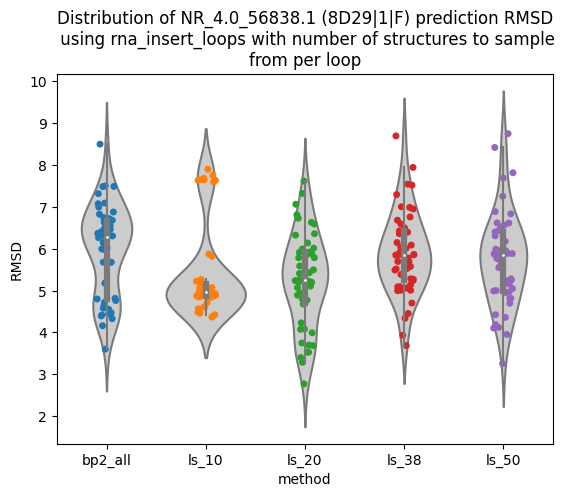

In [317]:

from matplotlib.collections import PathCollection
#plt.figure(figsize= (11,10))
dfri = new_df.reset_index()
keep = [ 'bp2_all',
 'loops_sample_10',
 'loops_sample_20',
 'loops_sample_38',
 'loops_sample_50']


dfri = dfri[dfri["method"].isin(keep)]
dfri = dfri.replace({"method": {
    #'bp2_all': ,
 'loops_sample_10': "ls_10",
 'loops_sample_20': "ls_20",
 'loops_sample_38' : "ls_38",
 'loops_sample_50': "ls_50",
}
             })
ax = sns.violinplot( data = dfri,  x = "method", y = "rmsd", color=".8")
for artist in ax.lines:
    artist.set_zorder(10)
for artist in ax.findobj(PathCollection):
    artist.set_zorder(11)
sns.stripplot( data = dfri,  x = "method", y = "rmsd")
plt.ylabel("RMSD")
plt.title(f"Distribution of {molecule} ({chains}) prediction RMSD\n using rna_insert_loops with number of structures to sample\nfrom per loop")

In [310]:
# find molecule with lowest RMSD
new_df.loc[new_df.groupby(["name", "method"])["rmsd"].idxmin()]

rmsd        pvalue    DI_ALL  \
name           method          instance                                     
NR_4.0_56838.1 bp2_all         out_0_39  3.602607  7.834459e-10  4.252500   
               bp2_reliable    out_0_11  4.662961  2.543535e-08  6.313679   
               from_native     1         1.737515  7.554513e-13  1.814775   
               loops_sample    11        4.461801  1.348908e-08  5.096796   
               loops_sample_10 37        4.368307  1.000375e-08  4.834059   
               loops_sample_20 36        2.772105  4.050432e-11  2.985850   
               loops_sample_38 40        3.687677  1.048790e-09  4.561883   
               loops_sample_50 9         3.257005  2.342218e-10  4.133891   
               loops_top       1         4.868570  4.803290e-08  5.426707   

                                          INF_ALL    INF_WC   INF_NWC  \
name           method          instance                                 
NR_4.0_56838.1 bp2_all         out_0_39  0.847174  0.818182  0.707107   
               bp2_reliable    out_0_11  0.738549  0.904534  0.000000   
               from_native     1         0.957427  1.000000  1.000000   
               loops_sample    11        0.875413  0.957427  0.500000   
               loops_sample_10 37        0.903652  0.957427  0.577350   
               loops_sample_20 36        0.928414  1.000000  1.000000   
               loops_sample_38 40        0.808367  0.904534  0.707107   
               loops_sample_50 9         0.787879  0.904534  0.707107   
               loops_top       1         0.897150  0.957427  0.577350   

                                         INF_STACK  
name           method          instance             
NR_4.0_56838.1 bp2_all         out_0_39   0.872872  
               bp2_reliable    out_0_11   0.697863  
               from_native     1          0.935414  
               loops_sample    11         0.883960  
               loops_sample_10 37         0.910032  
               loops_sample_20 36         0.890871  
               loops_sample_38 40         0.783547  
               loops_sample_50 9          0.744387  
               loops_top       1          0.898717

In [323]:
for r in new_df.loc[new_df.groupby(["name", "method"])["rmsd"].idxmin()].rows:
    print(r)

AttributeError: 'DataFrame' object has no attribute 'rows'

In [ ]:
df.